# Olist Marketplace Growth, Retention, and Customer Value Strategy

This project analyzes the Brazilian Olist e-commerce dataset as a marketplace strategy case study.

The goal is to understand how revenue growth, customer retention, logistics performance, seller concentration, product categories, and customer value connect inside a marketplace business. To make the analysis more structured, PostgreSQL is used for data modeling and analytical queries, while Python is used for visualization, experimentation logic, predictive modeling, and business interpretation.

Instead of treating the dataset as a simple exploratory analysis, I approach it as a real marketplace problem: where is value being created, where is growth becoming fragile, and which operational issues may be limiting long-term performance?

The project combines SQL-based data preparation, marketplace KPI analysis, cohort retention, customer value segmentation, logistics diagnostics, experimentation concepts, and lightweight predictive modeling.

# Executive Summary

This project analyzes the Brazilian Olist marketplace to understand where growth is coming from, how customer value is distributed, and which operational issues may be limiting long-term performance.

The analysis shows that Olist has meaningful commercial activity across different product categories, but also faces clear structural challenges. Repeat purchasing behavior is weak, customer value is highly concentrated, and logistics friction appears closely connected to lower customer satisfaction.

### Main Findings

- GMV is distributed across several product categories, but a smaller group of high-value customers, sellers, and strategic categories still explains a large share of marketplace activity.
- Retention is the main structural weakness of the marketplace: only 3.0% of customers place more than one order, and average month-1 cohort retention is approximately **0.44%** among cohorts with at least 100 customers.
- Customer value is highly concentrated, with the highest-value customer segment contributing nearly 60% of total GMV.
- Logistics performance matters for customer experience. Late deliveries and longer shipping routes are consistently associated with lower review scores.
- Categories such as **health_beauty** and **sports_leisure** combine scale with stronger customer satisfaction, while some large home-related categories show more operational friction.
- The simulated retention experiment suggests that discounts may increase conversion, but the short-term GMV impact becomes limited once discount costs are included.

### Strategic Implication

The biggest opportunity is not just increasing basket size. Based on the analysis, Olist would likely benefit more from improving repeat purchase behavior, delivery reliability, seller quality, and operational performance in strategically important categories.

# 1. Business Understanding

Olist works as a marketplace infrastructure platform, so growth is not only about increasing transaction volume. For the marketplace to be sustainable, customer experience, seller quality, delivery reliability, and repeat purchasing behavior also need to work well together.

With that in mind, this project looks at marketplace performance from both a commercial and operational perspective. The goal is to understand how GMV, retention, customer value, seller concentration, product categories, and logistics performance are connected across the marketplace.

Instead of only describing what happened, the analysis focuses on where growth may be fragile: which parts of the operation create friction, where customer experience breaks down, and what could limit long-term marketplace performance.

> **GMV note:** Throughout this notebook, GMV is used as a proxy for marketplace transaction volume, calculated as item price plus freight value. The dataset does not provide Olist's actual platform revenue, commissions, contribution margins, or operational costs.

## 1.1 Core Business Questions

To guide the analysis, I focus on five questions that connect marketplace growth, customer behavior, and operational performance:

1. Which categories, sellers, and customer regions contribute the most to marketplace GMV?
2. Is growth mainly coming from new customer acquisition or from repeat purchasing behavior?
3. How concentrated is marketplace value across customers, sellers, and product categories?
4. Which operational factors are associated with weaker customer satisfaction and retention?
5. Could a discount-based retention strategy improve repeat purchasing in a financially sustainable way?

## 1.2 Business Objectives

Based on these questions, the project focuses on turning marketplace data into practical business insight.

The main objectives are to:

- Measure marketplace growth and identify where GMV is really coming from.
- Understand how value is concentrated across customers, sellers, and product categories.
- Investigate why repeat purchasing behavior remains weak.
- Identify logistics and customer experience friction points that may affect satisfaction.
- Segment customers by realized value and highlight groups that may deserve more attention.
- Simulate retention-oriented interventions and compare conversion gains against GMV trade-offs.
- Translate the findings into realistic product, growth, and operational recommendations.

## 1.3 Working Hypotheses

Before moving into the analysis, I use a few working hypotheses to guide what should be tested and observed throughout the project:

1. Marketplace GMV is likely concentrated among a smaller group of sellers, customers, and product categories.
2. Longer shipping distances and delivery delays may be associated with weaker customer satisfaction.
3. Customer value is expected to be highly skewed, with a minority of customers generating a large share of marketplace GMV.
4. Retention incentives may improve short-term conversion, but their financial impact may become less clear once discount costs are included.

# 2. Environment Setup

This section initializes the analytical environment used throughout the notebook.

**PostgreSQL** is used as the main data layer for storing and querying the Olist relational dataset. **Python** is used for analysis, visualization, feature engineering, experimentation logic, and lightweight predictive modeling.

The setup includes:

* core analytical libraries
* visualization and display settings
* helper functions
* PostgreSQL connection required for the SQL-based workflow.

In [51]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import Markdown, display
from scipy import stats

from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
)

pd.set_option(
    "display.max_columns",
    100,
)

pd.set_option(
    "display.float_format",
    lambda x: f"{x:,.2f}",
)

sns.set_theme(
    style="whitegrid",
    context="notebook",
)

PALETTE = {
    "gmv": "#2F5597",
    "orders": "#2A9D8F",
    "aov": "#E76F51",
    "retention": "#6A4C93",
    "logistics": "#8D6E63",
    "negative": "#C44E52",
    "neutral": "#7A7A7A",
}

PROJECT_ROOT = Path("..")
IMAGE_DIR = PROJECT_ROOT / "images"

IMAGE_DIR.mkdir(
    exist_ok=True
)

> Interpretation
> * The notebook starts by preparing the main tools needed for analysis, visualization, SQL access, statistical checks, and predictive modeling.
> * Display and formatting settings are standardized early so tables, numeric values, and outputs remain easier to read throughout the project.
> * A consistent color palette is also defined to keep the visual storytelling coherent across GMV, orders, AOV, retention, logistics, risk, and neutral reference elements.
> * This setup keeps the analytical workflow organized before moving into the marketplace data itself.

In [52]:
def mode_or_first(series):
    series = series.dropna()

    if series.empty:
        return np.nan

    mode = series.mode()

    return (
        mode.iat[0]
        if not mode.empty
        else series.iloc[0]
    )


def haversine_km(
    lat1,
    lon1,
    lat2,
    lon2,
):
    lat1 = np.radians(lat1.astype(float))
    lon1 = np.radians(lon1.astype(float))
    lat2 = np.radians(lat2.astype(float))
    lon2 = np.radians(lon2.astype(float))

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )

    return (
        6371
        * 2
        * np.arcsin(np.sqrt(a))
    )

> Interpretation
> * The helper functions prepare a few operations that will be reused later in the analysis.
> * **mode_or_first()** is useful when aggregating categorical fields and choosing a representative value without creating unnecessary complexity.
> * **haversine_km()** estimates the distance between customers and sellers, supporting the logistics and delivery-friction analysis later in the notebook.

In [53]:
import os

from dotenv import load_dotenv
from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL

load_dotenv("../.env")

connection_url = URL.create(
    drivername="postgresql+psycopg2",
    username=os.getenv("POSTGRES_USER"),
    password=os.getenv("POSTGRES_PASSWORD"),
    host=os.getenv("POSTGRES_HOST"),
    port=os.getenv("POSTGRES_PORT"),
    database=os.getenv("POSTGRES_DB"),
)

engine = create_engine(connection_url)

with engine.connect() as conn:
    result = conn.execute(text("SELECT current_database();"))
    print(f"Connected to database: {result.scalar()}")

Connected to database: olist_marketplace


> Interpretation
> * The notebook is now connected to the PostgreSQL database where the Olist marketplace tables are stored.
> * Using SQL as the main data access layer keeps the workflow more structured than reading raw CSV files directly in the analysis notebook.
> * The connection check confirms that the analysis is running against the correct database before any marketplace queries are created.

# 3. Data Preparation

The Olist dataset is structured as a relational marketplace database, with separate tables for customers, orders, order items, payments, reviews, sellers, products, and geolocation records.

Since the raw CSV files were already imported into PostgreSQL, the first step is to validate the database structure and confirm the number of records available in each table.

From there, the preparation process builds three analytical layers:

- an **item-level** dataset for product, seller, category, pricing, freight, and logistics analysis;
- an **order-level** dataset for GMV, customer behavior, delivery performance, and satisfaction analysis;
- a **customer-level** dataset for retention, segmentation, and customer value analysis.

In [54]:
tables = [
    "customers",
    "products",
    "sellers",
    "orders",
    "order_items",
    "order_payments",
    "order_reviews",
    "geolocation",
    "product_category_translation",
]

dataset_overview_queries = []

for table in tables:
    query = f"""
    SELECT
        '{table}' AS dataset,
        COUNT(*) AS rows
    FROM {table}
    """
    dataset_overview_queries.append(query)

dataset_overview_query = "\nUNION ALL\n".join(dataset_overview_queries)

dataset_overview = pd.read_sql(
    dataset_overview_query,
    engine,
)

dataset_overview = (
    dataset_overview
    .sort_values("dataset")
    .reset_index(drop=True)
)

display(dataset_overview)

,dataset,rows
0,customers,99441
1,geolocation,1000163
2,order_items,112650
3,order_payments,103886
4,order_reviews,99224
5,orders,99441
6,product_category_translation,71
7,products,32951
8,sellers,3095


> Interpretation
> * The PostgreSQL tables are available and contain the expected record volumes for the Olist dataset.
> * Using the database as the main analytical layer keeps the notebook cleaner and avoids reloading raw CSV files during the analysis.
> * From this point forward, SQL handles the relational data access, while Python focuses on analysis, visualization, and business interpretation.

In [55]:
purchase_coverage_query = """
SELECT
    MIN(order_purchase_timestamp)::date AS purchase_start,
    MAX(order_purchase_timestamp)::date AS purchase_end
FROM orders;
"""

purchase_coverage = pd.read_sql(
    purchase_coverage_query,
    engine,
)

purchase_start = purchase_coverage.loc[0, "purchase_start"]
purchase_end = purchase_coverage.loc[0, "purchase_end"]

display(
    Markdown(
        f"""
> **Purchase coverage:** {purchase_start} to {purchase_end}
"""
    )
)


> **Purchase coverage:** 2016-09-04 to 2018-10-17


> Interpretation
> * The order data covers purchases from September 2016 to October 2018.
> * This time window is enough to analyze monthly growth, customer behavior, cohort retention, and operational performance.
> * Because 2016 and 2018 are incomplete years, yearly comparisons need caution. Monthly trends are a more reliable way to evaluate marketplace evolution.

## 3.1 Data Integration

The original Olist dataset is spread across several relational tables, including customers, sellers, products, payments, reviews, orders, and geolocation records.

In this step, I create reusable SQL views that enrich the raw marketplace data with product category translations, ZIP-code geolocation, payment summaries, and review summaries.

Keeping this integration inside PostgreSQL makes the workflow more organized and reproducible. It also avoids repeating the same joins throughout the notebook and creates a stronger foundation for the item-level, order-level, and customer-level analyses.

In [56]:
create_views_query = """
CREATE OR REPLACE VIEW vw_products_enriched AS
SELECT
    p.product_id,
    COALESCE(p.product_category_name, 'unknown') AS product_category_name,
    COALESCE(t.product_category_name_english, 'unknown') AS product_category_name_english,
    p.product_name_lenght,
    p.product_description_lenght,
    p.product_photos_qty,
    p.product_weight_g,
    p.product_length_cm,
    p.product_height_cm,
    p.product_width_cm
FROM products p
LEFT JOIN product_category_translation t
    ON p.product_category_name = t.product_category_name;


CREATE OR REPLACE VIEW vw_geo_zip AS
SELECT
    geolocation_zip_code_prefix,
    AVG(geolocation_lat) AS geolocation_lat,
    AVG(geolocation_lng) AS geolocation_lng,
    MODE() WITHIN GROUP (ORDER BY geolocation_city) AS geolocation_city,
    MODE() WITHIN GROUP (ORDER BY geolocation_state) AS geolocation_state
FROM geolocation
GROUP BY geolocation_zip_code_prefix;


CREATE OR REPLACE VIEW vw_customers_enriched AS
SELECT
    c.customer_id,
    c.customer_unique_id,
    c.customer_zip_code_prefix,
    c.customer_city,
    c.customer_state,
    g.geolocation_lat AS customer_lat,
    g.geolocation_lng AS customer_lng,
    g.geolocation_city AS customer_geo_city,
    g.geolocation_state AS customer_geo_state
FROM customers c
LEFT JOIN vw_geo_zip g
    ON c.customer_zip_code_prefix = g.geolocation_zip_code_prefix;


CREATE OR REPLACE VIEW vw_sellers_enriched AS
SELECT
    s.seller_id,
    s.seller_zip_code_prefix,
    s.seller_city,
    s.seller_state,
    g.geolocation_lat AS seller_lat,
    g.geolocation_lng AS seller_lng,
    g.geolocation_city AS seller_geo_city,
    g.geolocation_state AS seller_geo_state
FROM sellers s
LEFT JOIN vw_geo_zip g
    ON s.seller_zip_code_prefix = g.geolocation_zip_code_prefix;


CREATE OR REPLACE VIEW vw_payments_agg AS
SELECT
    order_id,
    SUM(payment_value) AS payment_value,
    MAX(payment_installments) AS payment_installments,
    MODE() WITHIN GROUP (ORDER BY payment_type) AS payment_type,
    COUNT(DISTINCT payment_type) AS payment_type_nunique
FROM order_payments
GROUP BY order_id;


CREATE OR REPLACE VIEW vw_reviews_agg AS
SELECT
    order_id,
    AVG(review_score) AS review_score,
    AVG(
        CASE
            WHEN review_comment_message IS NOT NULL THEN 1.0
            ELSE 0.0
        END
    ) AS review_comment_rate,
    COUNT(DISTINCT review_id) AS review_count
FROM order_reviews
GROUP BY order_id;


CREATE OR REPLACE VIEW vw_orders_enriched AS
SELECT
    o.order_id,
    o.customer_id,
    o.order_status,
    o.order_purchase_timestamp,
    o.order_approved_at,
    o.order_delivered_carrier_date,
    o.order_delivered_customer_date,
    o.order_estimated_delivery_date,

    c.customer_unique_id,
    c.customer_zip_code_prefix,
    c.customer_city,
    c.customer_state,
    c.customer_lat,
    c.customer_lng,
    c.customer_geo_city,
    c.customer_geo_state,

    p.payment_value,
    p.payment_installments,
    p.payment_type,
    p.payment_type_nunique,

    r.review_score,
    r.review_comment_rate,
    r.review_count
FROM orders o
LEFT JOIN vw_customers_enriched c
    ON o.customer_id = c.customer_id
LEFT JOIN vw_payments_agg p
    ON o.order_id = p.order_id
LEFT JOIN vw_reviews_agg r
    ON o.order_id = r.order_id;
"""

with engine.begin() as conn:
    conn.execute(text(create_views_query))

print("Analytical views created successfully.")

Analytical views created successfully.


> Interpretation
> * The main integration logic is now handled through reusable PostgreSQL views.
> * Product categories, customer and seller locations, payment behavior, and review information are prepared before the main analysis, making the later datasets easier to build.
> * Aggregating payments and reviews at the order level helps avoid duplicated values when calculating marketplace KPIs.
> * These views create the base layer for the item-level, order-level, and customer-level datasets used throughout the project.

In [57]:
views_check_query = """
SELECT
    table_name AS view_name
FROM information_schema.views
WHERE table_schema = 'public'
  AND table_name LIKE 'vw_%'
ORDER BY table_name;
"""

with engine.connect() as conn:
    views_check = pd.read_sql(
        text(views_check_query),
        conn,
    )

display(views_check)

,view_name
0,vw_category_summary
1,vw_cohort_retention
2,vw_completed_items
3,vw_completed_orders
4,vw_customer_level
5,vw_customers_enriched
6,vw_delivered_items
7,vw_delivered_orders
8,vw_distance_summary
9,vw_geo_zip


> Interpretation
> * The analytical SQL layer is now in place.
> * The **vw_** views separate reusable business logic from the raw tables, making the database structure easier to understand and reuse.
> * Keeping these views available in PostgreSQL reduces repeated join logic in later sections of the notebook.

## 3.2 Order-Level Feature Engineering

At this stage, the analysis moves from relational marketplace tables to a structured order-level dataset.

The goal is to create features that represent commercial performance, customer behavior, logistics conditions, and delivery experience at the order level. These features include GMV, freight participation, delivery performance, shipping distance, seller concentration, and other metrics needed for the next stages of the analysis.

### 3.2.1 Delivery and Time-Based Features

The first order-level features are built from the order lifecycle timestamps.

These variables capture delivery duration, approval delay, delivery punctuality, and purchase month. They help connect operational performance with customer experience, retention behavior, and marketplace growth trends.

In [58]:
order_time_features_query = """
SELECT
    order_id,
    customer_id,
    customer_unique_id,
    order_status,
    order_purchase_timestamp,
    order_approved_at,
    order_delivered_customer_date,
    order_estimated_delivery_date,

    EXTRACT(
        EPOCH FROM (
            order_delivered_customer_date - order_purchase_timestamp
        )
    ) / 86400.0 AS delivery_days,

    EXTRACT(
        EPOCH FROM (
            order_delivered_customer_date - order_estimated_delivery_date
        )
    ) / 86400.0 AS estimated_vs_actual_days,

    EXTRACT(
        EPOCH FROM (
            order_approved_at - order_purchase_timestamp
        )
    ) / 3600.0 AS approval_lag_hours,

    CASE
        WHEN order_delivered_customer_date > order_estimated_delivery_date THEN 1
        ELSE 0
    END AS is_late_delivery,

    DATE_TRUNC('month', order_purchase_timestamp)::date AS purchase_month

FROM vw_orders_enriched;
"""

with engine.connect() as conn:
    order_time_features = pd.read_sql(
        text(order_time_features_query),
        conn,
    )

display(
    order_time_features[
        [
            "order_id",
            "delivery_days",
            "estimated_vs_actual_days",
            "approval_lag_hours",
            "is_late_delivery",
            "purchase_month",
        ]
    ]
    .round(
        {
            "delivery_days": 1,
            "estimated_vs_actual_days": 1,
            "approval_lag_hours": 2,
        }
    )
    .head()
)

,order_id,delivery_days,estimated_vs_actual_days,approval_lag_hours,is_late_delivery,purchase_month
0,e481f51cbdc54678b7cc49136f2d6af7,8.40,-7.10,0.18,0,2017-10-01
1,ad21c59c0840e6cb83a9ceb5573f8159,2.90,-9.20,1.03,0,2018-02-01
2,a4591c265e18cb1dcee52889e2d8acc3,16.50,-5.50,0.22,0,2017-07-01
3,76c6e866289321a7c93b82b54852dc33,9.80,-31.40,32.36,0,2017-01-01
4,82566a660a982b15fb86e904c8d32918,12.10,-28.50,41.11,0,2018-06-01


> Interpretation
> * Delivery and approval timestamps are now converted into order-level operational indicators.
> * Delivery duration, approval lag, and late delivery flags help measure how efficiently orders move through the fulfillment process.
> * The purchase month creates the time foundation needed for growth, seasonality, cohort, and retention analysis later in the notebook.
> * These features help connect operational performance with customer experience instead of treating logistics as a separate topic.

### 3.2.2 Item-Level Commercial and Logistics Features

This step builds the item-level analytical layer, combining order items with product, seller, customer, payment, review, and logistics information.

The goal is to capture the commercial and operational structure behind each marketplace transaction. At this level, it becomes possible to analyze GMV, freight participation, product size, seller routing, and category performance before aggregating the data to the order and customer levels.

In [59]:
create_order_item_base_query = """
CREATE OR REPLACE VIEW vw_order_item_base AS
SELECT
    oi.order_id,
    oi.order_item_id,
    oi.product_id,
    oi.seller_id,
    oi.shipping_limit_date,
    oi.price,
    oi.freight_value,

    p.product_category_name,
    p.product_category_name_english,
    p.product_weight_g,
    p.product_length_cm,
    p.product_height_cm,
    p.product_width_cm,

    s.seller_zip_code_prefix,
    s.seller_city,
    s.seller_state,
    s.seller_lat,
    s.seller_lng,

    o.customer_id,
    o.customer_unique_id,
    o.customer_zip_code_prefix,
    o.customer_city,
    o.customer_state,
    o.customer_lat,
    o.customer_lng,
    o.order_status,
    o.order_purchase_timestamp,
    o.order_approved_at,
    o.order_delivered_customer_date,
    o.order_estimated_delivery_date,
    o.payment_value,
    o.payment_installments,
    o.payment_type,
    o.payment_type_nunique,
    o.review_score,
    o.review_comment_rate,
    o.review_count,

    oi.price + oi.freight_value AS item_gmv,

    oi.freight_value / NULLIF((oi.price + oi.freight_value), 0) AS freight_share,

    COALESCE(p.product_length_cm, 0)
        * COALESCE(p.product_height_cm, 0)
        * COALESCE(p.product_width_cm, 0) AS volume_cm3,

    CASE
        WHEN o.customer_state = s.seller_state THEN 1
        ELSE 0
    END AS same_state_route

FROM order_items oi
LEFT JOIN vw_products_enriched p
    ON oi.product_id = p.product_id
LEFT JOIN vw_sellers_enriched s
    ON oi.seller_id = s.seller_id
LEFT JOIN vw_orders_enriched o
    ON oi.order_id = o.order_id;
"""

with engine.begin() as conn:
    conn.execute(text(create_order_item_base_query))

> Interpretation
> * The item-level analytical view is now available in PostgreSQL.
> * This view centralizes the main transaction, product, seller, customer, payment, review, and logistics fields needed for the next analyses.
> * Keeping this structure in SQL makes the workflow easier to reuse and avoids rebuilding the same joins later in the notebook.

In [60]:
order_item_preview_query = """
SELECT
    order_id,
    product_category_name_english,
    item_gmv,
    freight_share,
    volume_cm3,
    same_state_route
FROM vw_order_item_base
LIMIT 5;
"""

with engine.connect() as conn:
    order_item_preview = pd.read_sql(
        text(order_item_preview_query),
        conn,
    )

display(
    order_item_preview.round(
        {
            "item_gmv": 2,
            "freight_share": 2,
            "volume_cm3": 0,
        }
    )
)

,order_id,product_category_name_english,item_gmv,freight_share,volume_cm3,same_state_route
0,00010242fe8c5a6d1ba2dd792cb16214,cool_stuff,72.19,0.18,3528,0
1,00018f77f2f0320c557190d7a144bdd3,pet_shop,259.83,0.08,60000,1
2,000229ec398224ef6ca0657da4fc703e,furniture_decor,216.87,0.08,14157,1
3,00024acbcdf0a6daa1e931b038114c75,perfumery,25.78,0.50,2400,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,garden_tools,218.04,0.08,42000,0


> Interpretation
> * The preview confirms that the item-level dataset is combining commercial and logistics features correctly.
> * Each row represents an order item enriched with product category, GMV, freight share, product volume, and routing information.
> * These variables will support later analysis of category performance, freight pressure, seller operations, and marketplace value concentration.

### 3.2.3 Geographic Distance Features

This step adds an estimated geographic distance between customers and sellers using ZIP-code latitude and longitude coordinates.

The distance is not a perfect shipping-route measure, since it is based on geographic coordinates rather than actual road distance. Still, it provides a useful proxy for logistics complexity, helping analyze freight costs, delivery performance, cross-state routes, and customer experience.

In [61]:
create_order_item_geo_query = """
CREATE OR REPLACE VIEW vw_order_item_geo AS
SELECT
    *,

    CASE
        WHEN customer_lat IS NOT NULL
         AND customer_lng IS NOT NULL
         AND seller_lat IS NOT NULL
         AND seller_lng IS NOT NULL
        THEN
            6371 * 2 * ASIN(
                SQRT(
                    POWER(SIN(RADIANS(seller_lat - customer_lat) / 2), 2)
                    +
                    COS(RADIANS(customer_lat))
                    * COS(RADIANS(seller_lat))
                    * POWER(SIN(RADIANS(seller_lng - customer_lng) / 2), 2)
                )
            )
        ELSE NULL
    END AS distance_km

FROM vw_order_item_base;
"""

with engine.begin() as conn:
    conn.execute(text(create_order_item_geo_query))

> Interpretation
> * The item-level dataset now includes an estimated customer-to-seller distance.
> * This distance is calculated from ZIP-code coordinates, so it should be interpreted as a logistics proxy rather than an exact delivery route.
> * Adding this feature in PostgreSQL keeps the geographic logic reusable for freight, delivery, seller, and customer experience analysis.

In [62]:
distance_preview_query = """
SELECT
    order_id,
    customer_state,
    seller_state,
    distance_km
FROM vw_order_item_geo
LIMIT 5;
"""

with engine.connect() as conn:
    distance_preview = pd.read_sql(
        text(distance_preview_query),
        conn,
    )

display(
    distance_preview.round(
        {
            "distance_km": 1,
        }
    )
)

,order_id,customer_state,seller_state,distance_km
0,00010242fe8c5a6d1ba2dd792cb16214,RJ,SP,301.50
1,00018f77f2f0320c557190d7a144bdd3,SP,SP,585.60
2,000229ec398224ef6ca0657da4fc703e,MG,MG,312.30
3,00024acbcdf0a6daa1e931b038114c75,SP,SP,293.20
4,00042b26cf59d7ce69dfabb4e55b4fd9,SP,PR,646.20


> Interpretation
> * The preview confirms that geographic distance is available at the item level.
> * Same-state routes can still show long distances, which makes sense in a large country like Brazil and is visible in some of the examples.
> * This feature will help evaluate whether longer routes are associated with higher freight share, slower delivery, weaker review scores, or lower retention.

### 3.2.4 Order-Level Aggregation

After building the item-level commercial, operational, and geographic features, the next step is to aggregate the data into a consolidated order-level dataset.

This structure creates one observation per order, combining customer, payment, fulfillment, product, seller, GMV, freight, category, and logistics information. It becomes the main analytical base for marketplace performance, retention, customer behavior, and customer value analysis.

In [63]:
create_order_level_query = """
CREATE OR REPLACE VIEW vw_order_level AS
WITH order_agg AS (
    SELECT
        order_id,

        MAX(customer_unique_id) AS customer_unique_id,
        MAX(customer_state) AS customer_state,
        MAX(order_status) AS order_status,
        MAX(order_purchase_timestamp) AS order_purchase_timestamp,
        MAX(order_approved_at) AS order_approved_at,
        MAX(order_delivered_customer_date) AS order_delivered_customer_date,
        MAX(order_estimated_delivery_date) AS order_estimated_delivery_date,

        MAX(review_score) AS review_score,
        MAX(payment_value) AS payment_value,
        MAX(payment_installments) AS payment_installments,
        MODE() WITHIN GROUP (ORDER BY payment_type) AS payment_type,

        SUM(item_gmv) AS order_gmv,
        SUM(freight_value) AS freight_gmv,
        COUNT(order_item_id) AS item_count,
        COUNT(DISTINCT seller_id) AS seller_count,
        COUNT(DISTINCT product_category_name_english) AS category_count,
        MODE() WITHIN GROUP (ORDER BY product_category_name_english) AS dominant_category,
        AVG(distance_km) AS avg_distance_km

    FROM vw_order_item_geo
    GROUP BY order_id
)

SELECT
    *,

    EXTRACT(
        EPOCH FROM (
            order_delivered_customer_date - order_purchase_timestamp
        )
    ) / 86400.0 AS delivery_days,

    EXTRACT(
        EPOCH FROM (
            order_delivered_customer_date - order_estimated_delivery_date
        )
    ) / 86400.0 AS estimated_vs_actual_days,

    EXTRACT(
        EPOCH FROM (
            order_approved_at - order_purchase_timestamp
        )
    ) / 3600.0 AS approval_lag_hours,

    CASE
        WHEN order_delivered_customer_date > order_estimated_delivery_date THEN 1
        ELSE 0
    END AS is_late_delivery,

    DATE_TRUNC('month', order_purchase_timestamp)::date AS purchase_month,

    payment_value - order_gmv AS gmv_payment_gap

FROM order_agg;
"""

with engine.begin() as conn:
    conn.execute(text(create_order_level_query))

> Interpretation
> * The order-level analytical dataset is now available in PostgreSQL.
> * Each row represents one order, with commercial, payment, customer, category, seller, delivery, and distance information consolidated from the item-level layer.
> * Aggregating the data at this level makes the next marketplace KPIs more reliable, especially for GMV, retention, satisfaction, and operational analysis.

In [64]:
create_order_filters_query = """
CREATE OR REPLACE VIEW vw_completed_orders AS
SELECT *
FROM vw_order_level
WHERE order_status IN (
    'delivered',
    'shipped',
    'invoiced',
    'processing',
    'approved'
);

CREATE OR REPLACE VIEW vw_delivered_orders AS
SELECT *
FROM vw_order_level
WHERE order_status = 'delivered';

CREATE OR REPLACE VIEW vw_completed_items AS
SELECT *
FROM vw_order_item_geo
WHERE order_status IN (
    'delivered',
    'shipped',
    'invoiced',
    'processing',
    'approved'
);

CREATE OR REPLACE VIEW vw_delivered_items AS
SELECT *
FROM vw_order_item_geo
WHERE order_status = 'delivered';
"""

with engine.begin() as conn:
    conn.execute(text(create_order_filters_query))

> Interpretation
> * Separate views are now available for completed and delivered orders.
> * Completed orders are useful for GMV and marketplace activity analysis, while delivered orders are safer for logistics, delivery, and satisfaction analysis.
> * Keeping these filters in PostgreSQL avoids redefining the same order-status logic throughout the notebook.

In [65]:
order_level_preview_query = """
SELECT
    order_id,
    customer_state,
    order_status,
    order_gmv,
    delivery_days,
    is_late_delivery,
    avg_distance_km,
    dominant_category
FROM vw_completed_orders
LIMIT 5;
"""

with engine.connect() as conn:
    order_level_preview = pd.read_sql(
        text(order_level_preview_query),
        conn,
    )

display(
    order_level_preview.round(
        {
            "order_gmv": 2,
            "delivery_days": 1,
            "avg_distance_km": 1,
        }
    )
)

,order_id,customer_state,order_status,order_gmv,delivery_days,is_late_delivery,avg_distance_km,dominant_category
0,00010242fe8c5a6d1ba2dd792cb16214,RJ,delivered,72.19,7.60,0,301.50,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,SP,delivered,259.83,16.20,0,585.60,pet_shop
2,000229ec398224ef6ca0657da4fc703e,MG,delivered,216.87,7.90,0,312.30,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,SP,delivered,25.78,6.10,0,293.20,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,SP,delivered,218.04,25.10,0,646.20,garden_tools


> Interpretation
> * The preview confirms that the order-level dataset is structured as expected, with one row per order.
> * GMV, delivery performance, route distance, and dominant product category are now available together in the same analytical layer.
> * This dataset becomes the main base for the next sections, especially marketplace growth, retention, customer value, and operational performance.

## 3.3 Customer-Level Aggregation

After building the order-level dataset, the next step is to consolidate marketplace activity at the customer level.

This layer focuses on purchase frequency, monetary contribution, recency, retention behavior, customer satisfaction, delivery experience, and realized customer value. It creates the foundation for segmentation, retention analysis, and LTV-oriented business interpretation.

In [66]:
create_customer_level_query = """
CREATE OR REPLACE VIEW vw_customer_level AS
WITH analysis_window AS (
    SELECT
        MAX(order_purchase_timestamp) AS analysis_end
    FROM vw_completed_orders
),

customer_agg AS (
    SELECT
        customer_unique_id,

        SUM(order_gmv) AS total_gmv,
        COUNT(DISTINCT order_id) AS total_orders,

        MIN(order_purchase_timestamp) AS first_purchase,
        MAX(order_purchase_timestamp) AS last_purchase,

        AVG(order_gmv) AS avg_order_value,
        AVG(review_score) AS avg_review_score,
        AVG(delivery_days) AS avg_delivery_days,
        AVG(is_late_delivery::numeric) AS late_delivery_rate

    FROM vw_completed_orders
    GROUP BY customer_unique_id
),

customer_features AS (
    SELECT
        c.*,

        EXTRACT(
            EPOCH FROM (
                aw.analysis_end - c.last_purchase
            )
        ) / 86400.0 AS recency_days,

        GREATEST(
            EXTRACT(
                EPOCH FROM (
                    c.last_purchase - c.first_purchase
                )
            ) / 86400.0,
            0
        ) AS tenure_days,

        CASE
            WHEN EXTRACT(
                EPOCH FROM (
                    c.last_purchase - c.first_purchase
                )
            ) / 86400.0 > 0
            THEN
                c.total_orders / (
                    (
                        EXTRACT(
                            EPOCH FROM (
                                c.last_purchase - c.first_purchase
                            )
                        ) / 86400.0
                    ) / 30.4
                )
            ELSE NULL
        END AS purchase_frequency_per_month,

        c.total_gmv AS realized_ltv,

        CASE
            WHEN c.total_orders > 1 THEN 1
            ELSE 0
        END AS repeat_customer

    FROM customer_agg c
    CROSS JOIN analysis_window aw
),

customer_segments AS (
    SELECT
        *,

        NTILE(4) OVER (
            ORDER BY realized_ltv
        ) AS value_quartile

    FROM customer_features
)

SELECT
    *,

    CASE
        WHEN value_quartile = 1 THEN 'Low'
        WHEN value_quartile = 2 THEN 'Mid-Low'
        WHEN value_quartile = 3 THEN 'Mid-High'
        WHEN value_quartile = 4 THEN 'High'
    END AS value_segment

FROM customer_segments;
"""

with engine.begin() as conn:
    conn.execute(text(create_customer_level_query))

> Interpretation
> * The customer-level analytical layer is now available in PostgreSQL.
> * Purchase behavior, monetary value, recency, delivery experience, satisfaction, and repeat purchasing indicators are consolidated into one row per customer.
> * This structure makes it easier to analyze retention and customer value without repeatedly recalculating metrics from the order-level data.

In [67]:
customer_level_preview_query = """
SELECT
    customer_unique_id,
    total_orders,
    total_gmv,
    avg_order_value,
    recency_days,
    purchase_frequency_per_month,
    repeat_customer,
    value_segment
FROM vw_customer_level
ORDER BY customer_unique_id
LIMIT 5;
"""

with engine.connect() as conn:
    customer_level_preview = pd.read_sql(
        text(customer_level_preview_query),
        conn,
    )

display(
    customer_level_preview
    .fillna(
        {
            "purchase_frequency_per_month": 0,
        }
    )
    .round(
        {
            "total_gmv": 2,
            "avg_order_value": 2,
            "recency_days": 0,
            "purchase_frequency_per_month": 2,
        }
    )
)

,customer_unique_id,total_orders,total_gmv,avg_order_value,recency_days,purchase_frequency_per_month,repeat_customer,value_segment
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,141.90,116.00,0,0,Mid-High
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,27.19,119.00,0,0,Low
2,0000f46a3911fa3c0805444483337064,1,86.22,86.22,542.00,0,0,Mid-Low
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,43.62,326.00,0,0,Low
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,196.89,293.00,0,0,High


> Interpretation
> * The preview confirms that each customer now has a consolidated behavioral and value profile.
> * Most customers in the sample have only one order, which already signals how important retention will be in the rest of the analysis.
> * Recency, frequency, realized LTV, and value segment provide a practical customer-level foundation for segmentation and retention diagnostics.

## 3.4 Marketplace KPI Tables

With the item-level, order-level, and customer-level layers prepared, the next step is to create the main KPI tables for the marketplace analysis.

These tables summarize performance across time, customers, sellers, product categories, and logistics dimensions. They will be used throughout the next sections to evaluate growth, retention, value concentration, operational quality, and strategic opportunities.

### 3.4.1 Monthly Growth Metrics

The first KPI table focuses on monthly marketplace growth.

These metrics track GMV, order volume, active customers, and average order value over time. Together, they provide a high-level view of marketplace expansion and help separate growth driven by customer acquisition from growth driven by higher order value or repeat activity.

In [68]:
create_monthly_metrics_query = """
CREATE OR REPLACE VIEW vw_monthly_metrics AS
SELECT
    purchase_month,
    SUM(order_gmv) AS gmv,
    COUNT(DISTINCT order_id) AS orders,
    COUNT(DISTINCT customer_unique_id) AS active_customers,
    SUM(order_gmv) / NULLIF(COUNT(DISTINCT order_id), 0) AS aov
FROM vw_completed_orders
GROUP BY purchase_month;
"""

with engine.begin() as conn:
    conn.execute(text(create_monthly_metrics_query))

> Interpretation
> * Monthly marketplace KPIs are now available in PostgreSQL.
> * GMV, order volume, active customers, and average order value are aggregated at the month level to support the growth analysis.
> * Keeping these metrics as a reusable SQL view makes the next visual and strategic sections cleaner.

In [69]:
monthly_metrics_query = """
SELECT
    purchase_month,
    gmv,
    orders,
    active_customers,
    aov
FROM vw_monthly_metrics
ORDER BY purchase_month;
"""

with engine.connect() as conn:
    monthly_metrics = pd.read_sql(
        text(monthly_metrics_query),
        conn,
    )

monthly_metrics_full = monthly_metrics[
    monthly_metrics["purchase_month"]
    < monthly_metrics["purchase_month"].max()
].copy()

display(
    monthly_metrics
    .head()
    .round(2)
)

,purchase_month,gmv,orders,active_customers,aov
0,2016-09-01,279.69,2,2,139.84
1,2016-10-01,"51,354.52",290,287,177.08
2,2016-12-01,19.62,1,1,19.62
3,2017-01-01,"136,943.46",787,753,174.01
4,2017-02-01,"283,561.69",1718,1693,165.05


> Interpretation
> * The monthly KPI table shows how GMV, orders, active customers, and AOV evolve over time.
> * The first months are sparse, so the early operational period should be interpreted carefully when analyzing growth.
> * Active customers and order volume move closely together, giving an early signal that marketplace expansion may be driven more by acquisition than by repeat purchasing.
> * This table becomes the base for the upcoming growth, seasonality, and marketplace maturity analysis.

### 3.4.2 Customer Acquisition and Repeat Mix

Beyond overall marketplace growth, it is important to understand whether expansion is coming mostly from new customers or from repeat purchasing behavior.

This KPI table separates first purchases from repeat orders at the monthly level. It helps evaluate how much of the marketplace activity depends on acquisition and how much comes from customers returning to buy again.

In [70]:
create_monthly_customer_mix_query = """
CREATE OR REPLACE VIEW vw_monthly_customer_mix AS
WITH customer_order_sequence AS (
    SELECT
        order_id,
        customer_unique_id,
        purchase_month,
        order_purchase_timestamp,

        ROW_NUMBER() OVER (
            PARTITION BY customer_unique_id
            ORDER BY order_purchase_timestamp, order_id
        ) AS order_rank

    FROM vw_completed_orders
),

order_flags AS (
    SELECT
        *,
        CASE
            WHEN order_rank = 1 THEN 1
            ELSE 0
        END AS is_new_order,

        CASE
            WHEN order_rank > 1 THEN 1
            ELSE 0
        END AS is_repeat_order

    FROM customer_order_sequence
)

SELECT
    purchase_month,
    COUNT(DISTINCT customer_unique_id) AS active_customers,
    SUM(is_new_order) AS new_customers,
    SUM(is_repeat_order) AS repeat_orders,
    COUNT(DISTINCT order_id) AS total_orders,
    COUNT(DISTINCT customer_unique_id) - SUM(is_new_order) AS returning_customer_proxy,
    SUM(is_repeat_order)::numeric / NULLIF(COUNT(DISTINCT order_id), 0) AS repeat_order_share
FROM order_flags
GROUP BY purchase_month;
"""

with engine.begin() as conn:
    conn.execute(text(create_monthly_customer_mix_query))

> Interpretation
> * The monthly customer mix view separates first-time purchases from repeat orders.
> * Ranking each customer’s orders makes it possible to distinguish acquisition-driven activity from returning-customer behavior.
> * This structure will help evaluate whether marketplace growth is being sustained by retention or mainly by continuous new customer acquisition.

In [71]:
monthly_customer_mix_query = """
SELECT
    purchase_month,
    active_customers,
    new_customers,
    repeat_orders,
    repeat_order_share
FROM vw_monthly_customer_mix
ORDER BY purchase_month;
"""

with engine.connect() as conn:
    monthly_customer_mix = pd.read_sql(
        text(monthly_customer_mix_query),
        conn,
    )

display(
    monthly_customer_mix
    .head()
    .round(
        {
            "repeat_order_share": 2,
        }
    )
)

,purchase_month,active_customers,new_customers,repeat_orders,repeat_order_share
0,2016-09-01,2,2,0,0.00
1,2016-10-01,287,287,3,0.01
2,2016-12-01,1,1,0,0.00
3,2017-01-01,753,752,35,0.04
4,2017-02-01,1693,1690,28,0.02


> Interpretation
> * The first months already show that most marketplace activity comes from first-time buyers.
> * Repeat orders appear early, but their share remains very small compared with total order volume.
> * This reinforces an important theme for the project: growth exists, but the marketplace still needs stronger repeat purchasing behavior to become more sustainable.

> **Methodological note:** In this analysis, “new customers” means customers making their first purchase observed in the dataset. Since the dataset may not include the full historical relationship between each customer and Olist, this should be interpreted as a first observed purchase rather than a guaranteed first-ever purchase.

### 3.4.3 Category and Seller KPI Tables

Marketplace performance is usually concentrated across a smaller set of categories and sellers.

This step creates category-level and seller-level KPI tables to identify the most commercially relevant product verticals and merchants. Besides GMV and order volume, the tables also include review scores, freight intensity, customer reach, and late delivery rates, helping connect commercial performance with operational quality.

In [72]:
create_category_seller_kpis_query = """
CREATE OR REPLACE VIEW vw_category_summary AS
SELECT
    product_category_name_english,
    SUM(item_gmv) AS gmv,
    COUNT(DISTINCT order_id) AS orders,
    AVG(review_score) AS avg_review,
    SUM(freight_value) / NULLIF(SUM(item_gmv), 0) AS avg_freight_share
FROM vw_completed_items
GROUP BY product_category_name_english;


CREATE OR REPLACE VIEW vw_seller_summary AS
WITH seller_base AS (
    SELECT
        i.seller_id,
        SUM(i.item_gmv) AS gmv,
        COUNT(DISTINCT i.order_id) AS orders,
        COUNT(DISTINCT i.customer_unique_id) AS customers,
        AVG(i.review_score) AS avg_review,
        AVG(o.is_late_delivery::numeric) AS late_delivery_rate
    FROM vw_completed_items i
    LEFT JOIN vw_order_level o
        ON i.order_id = o.order_id
    GROUP BY i.seller_id
)

SELECT
    *,
    SUM(gmv) OVER (
        ORDER BY gmv DESC
        ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
    ) / SUM(gmv) OVER () AS cumulative_gmv_share
FROM seller_base;
"""

with engine.begin() as conn:
    conn.execute(text(create_category_seller_kpis_query))

> Interpretation
> * Category and seller KPI views are now available in PostgreSQL.
> * These views summarize GMV, order volume, customer reach, review scores, freight intensity, and delivery reliability across the marketplace.
> * This structure helps evaluate not only where revenue is concentrated, but also where operational quality may be weaker.

In [73]:
category_summary_query = """
SELECT
    product_category_name_english,
    gmv,
    orders,
    avg_review,
    avg_freight_share
FROM vw_category_summary
ORDER BY gmv DESC
LIMIT 5;
"""

with engine.connect() as conn:
    category_summary = pd.read_sql(
        text(category_summary_query),
        conn,
    )

display(
    category_summary.round(
        {
            "gmv": 2,
            "avg_review": 2,
            "avg_freight_share": 2,
        }
    )
)

,product_category_name_english,gmv,orders,avg_review,avg_freight_share
0,health_beauty,"1,437,665.78",8800,4.15,0.13
1,watches_gifts,"1,298,292.47",5604,4.03,0.08
2,bed_bath_table,"1,240,386.13",9399,3.90,0.16
3,sports_leisure,"1,147,244.63",7673,4.12,0.15
4,computers_accessories,"1,050,941.58",6654,3.95,0.14


> Interpretation
> * The top categories show where marketplace GMV is most concentrated.
> * Categories such as **health_beauty**, **watches_gifts**, and **bed_bath_table** combine strong commercial relevance with different levels of customer satisfaction and freight pressure.
> * Comparing GMV with review scores and freight share helps identify categories that are commercially important but may also carry more operational complexity.

In [74]:
seller_summary_query = """
SELECT
    seller_id,
    gmv,
    orders,
    customers,
    avg_review,
    late_delivery_rate
FROM vw_seller_summary
ORDER BY gmv DESC
LIMIT 5;
"""

with engine.connect() as conn:
    seller_summary = pd.read_sql(
        text(seller_summary_query),
        conn,
    )

display(
    seller_summary.round(
        {
            "gmv": 2,
            "avg_review": 2,
            "late_delivery_rate": 2,
        }
    )
)

,seller_id,gmv,orders,customers,avg_review,late_delivery_rate
0,4869f7a5dfa277a7dca6462dcf3b52b2,"249,393.44",1131,1123,4.13,0.12
1,7c67e1448b00f6e969d365cea6b010ab,"239,536.44",982,971,3.34,0.10
2,53243585a1d6dc2643021fd1853d8905,"235,856.68",358,349,4.08,0.04
3,4a3ca9315b744ce9f8e9374361493884,"235,359.30",1804,1790,3.80,0.11
4,fa1c13f2614d7b5c4749cbc52fecda94,"202,861.67",584,581,4.34,0.10


> Interpretation
> * The seller summary highlights how marketplace value is concentrated among top-performing merchants.
> * Even among the highest-GMV sellers, review scores and late delivery rates vary, suggesting that commercial scale does not always mean consistent operational quality.
> * This table will support later analysis of seller dependency, GMV concentration, and operational bottlenecks.

### 3.4.4 Geographic, Route, and Distance Summaries

Marketplace logistics performance is strongly shaped by geography, shipping routes, and customer-seller distance.

This step creates KPI tables by customer state, route type, and distance bucket. These summaries help evaluate how geographic complexity relates to GMV, freight costs, delivery performance, and customer satisfaction.

In [75]:
create_geo_route_distance_kpis_query = """
CREATE OR REPLACE VIEW vw_state_summary AS
SELECT
    customer_state,
    SUM(order_gmv) AS gmv,
    COUNT(DISTINCT order_id) AS orders,
    COUNT(DISTINCT customer_unique_id) AS customers,
    AVG(review_score) AS avg_review,
    SUM(order_gmv) / NULLIF(COUNT(DISTINCT order_id), 0) AS avg_order_value
FROM vw_completed_orders
GROUP BY customer_state;


CREATE OR REPLACE VIEW vw_route_summary AS
SELECT
    CASE
        WHEN same_state_route = 1 THEN 'same_state'
        ELSE 'cross_state'
    END AS route_type,

    COUNT(*) AS items,
    SUM(item_gmv) AS gmv,
    AVG(freight_value) AS avg_freight,
    AVG(review_score) AS avg_review,
    SUM(item_gmv) / NULLIF(
        SUM(SUM(item_gmv)) OVER (),
        0
    ) AS gmv_share
FROM vw_completed_items
GROUP BY
    CASE
        WHEN same_state_route = 1 THEN 'same_state'
        ELSE 'cross_state'
    END;


CREATE OR REPLACE VIEW vw_distance_summary AS
WITH distance_base AS (
    SELECT
        distance_km,
        freight_value,
        review_score,
        NTILE(5) OVER (
            ORDER BY distance_km
        ) AS distance_bucket
    FROM vw_completed_items
    WHERE distance_km IS NOT NULL
)

SELECT
    distance_bucket,
    AVG(distance_km) AS avg_distance_km,
    AVG(freight_value) AS avg_freight,
    AVG(review_score) AS avg_review
FROM distance_base
GROUP BY distance_bucket;
"""

with engine.begin() as conn:
    conn.execute(text(create_geo_route_distance_kpis_query))

> Interpretation
> * Geographic, route, and distance KPI views are now available in PostgreSQL.
> * These summaries connect marketplace performance with customer location, shipping structure, freight costs, and review behavior.
> * Keeping these aggregations in SQL makes the logistics analysis easier to reuse in the next sections.

In [76]:
state_summary_query = """
SELECT
    customer_state,
    gmv,
    orders,
    avg_review,
    avg_order_value
FROM vw_state_summary
ORDER BY gmv DESC
LIMIT 5;
"""

with engine.connect() as conn:
    state_summary = pd.read_sql(
        text(state_summary_query),
        conn,
    )

display(
    state_summary.round(
        {
            "gmv": 2,
            "avg_review": 2,
            "avg_order_value": 2,
        }
    )
)

,customer_state,gmv,orders,avg_review,avg_order_value
0,SP,"5,878,132.06",41125,4.21,142.93
1,RJ,"2,115,667.56",12697,3.90,166.63
2,MG,"1,843,074.43",11496,4.16,160.32
3,RS,"877,290.59",5415,4.16,162.01
4,PR,"794,196.61",4982,4.21,159.41


> Interpretation
> * The state summary shows that marketplace GMV is heavily concentrated in a few large customer markets.
> * São Paulo leads by a wide margin, followed by Rio de Janeiro and Minas Gerais.
> * Differences in average review scores and order value suggest that regional performance should be evaluated beyond volume alone.

In [77]:
route_summary_query = """
SELECT
    route_type,
    items,
    gmv,
    avg_freight,
    avg_review,
    gmv_share
FROM vw_route_summary
ORDER BY gmv DESC;
"""

with engine.connect() as conn:
    route_summary = pd.read_sql(
        text(route_summary_query),
        conn,
    )

display(
    route_summary.round(
        {
            "gmv": 2,
            "avg_freight": 2,
            "avg_review": 2,
            "gmv_share": 2,
        }
    )
)

,route_type,items,gmv,avg_freight,avg_review,gmv_share
0,cross_state,71639,"10,981,152.31",23.69,3.98,0.70
1,same_state,40462,"4,754,374.72",13.45,4.16,0.30


> Interpretation
> * Cross-state transactions represent most item-level GMV, showing that Olist depends strongly on long-distance marketplace routing.
> * Same-state routes have lower average freight and slightly higher review scores, suggesting a smoother logistics experience.
> * This comparison helps separate commercial reach from operational friction.

In [78]:
distance_summary_query = """
SELECT
    distance_bucket,
    avg_distance_km,
    avg_freight,
    avg_review
FROM vw_distance_summary
ORDER BY distance_bucket;
"""

with engine.connect() as conn:
    distance_summary = pd.read_sql(
        text(distance_summary_query),
        conn,
    )

display(
    distance_summary.round(
        {
            "avg_distance_km": 2,
            "avg_freight": 2,
            "avg_review": 2,
        }
    )
)

,distance_bucket,avg_distance_km,avg_freight,avg_review
0,1,44.54,11.92,4.19
1,2,253.56,17.45,4.07
2,3,432.58,19.74,4.03
3,4,693.56,21.18,3.99
4,5,"1,565.02",29.63,3.94


> Interpretation
> * Distance buckets show a clear increase in average freight as customer-seller distance grows.
> * Review scores gradually decline across longer-distance buckets, suggesting that logistics complexity may be connected to weaker customer experience.
> * Since distance is based on ZIP-code coordinates, this should be interpreted as a geographic proxy rather than an exact delivery-route measure.

### 3.4.5 Cohort Retention Table

To evaluate long-term customer engagement, this step builds a cohort retention table based on each customer’s first observed purchase month.

The goal is to measure how customer activity changes after acquisition and understand whether the marketplace sustains repeat purchasing behavior over time or depends mostly on continuous customer acquisition.

> **Methodological note:** In this notebook, cohort month refers to the first purchase observed in the dataset. Since the data may not include the full customer history before September 2016, retention should be interpreted as observed retention within the available dataset window.

In [79]:
create_cohort_retention_query = """
CREATE OR REPLACE VIEW vw_cohort_retention AS
WITH cohort_base AS (
    SELECT
        customer_unique_id,
        order_id,
        DATE_TRUNC('month', order_purchase_timestamp)::date AS order_month,
        MIN(DATE_TRUNC('month', order_purchase_timestamp)::date) OVER (
            PARTITION BY customer_unique_id
        ) AS cohort_month
    FROM vw_completed_orders
),

cohort_activity AS (
    SELECT
        customer_unique_id,
        cohort_month,
        order_month,
        (
            (EXTRACT(YEAR FROM order_month) - EXTRACT(YEAR FROM cohort_month)) * 12
            + (EXTRACT(MONTH FROM order_month) - EXTRACT(MONTH FROM cohort_month))
        )::int AS cohort_index
    FROM cohort_base
),

cohort_sizes AS (
    SELECT
        cohort_month,
        COUNT(DISTINCT customer_unique_id) AS cohort_size
    FROM cohort_activity
    WHERE cohort_index = 0
    GROUP BY cohort_month
),

cohort_counts AS (
    SELECT
        cohort_month,
        cohort_index,
        COUNT(DISTINCT customer_unique_id) AS customers
    FROM cohort_activity
    GROUP BY
        cohort_month,
        cohort_index
),

max_month AS (
    SELECT
        MAX(order_month) AS max_order_month
    FROM cohort_activity
),

cohort_grid AS (
    SELECT
        cs.cohort_month,
        generate_series(
            0,
            (
                (EXTRACT(YEAR FROM mm.max_order_month) - EXTRACT(YEAR FROM cs.cohort_month)) * 12
                + (EXTRACT(MONTH FROM mm.max_order_month) - EXTRACT(MONTH FROM cs.cohort_month))
            )::int
        ) AS cohort_index,
        cs.cohort_size
    FROM cohort_sizes cs
    CROSS JOIN max_month mm
)

SELECT
    g.cohort_month,
    g.cohort_index,
    COALESCE(c.customers, 0) AS customers,
    g.cohort_size,
    COALESCE(c.customers, 0)::numeric / NULLIF(g.cohort_size, 0) AS retention
FROM cohort_grid g
LEFT JOIN cohort_counts c
    ON g.cohort_month = c.cohort_month
   AND g.cohort_index = c.cohort_index;
"""

with engine.begin() as conn:
    conn.execute(text(create_cohort_retention_query))

> Interpretation
> * The cohort retention view is now available in PostgreSQL.
> * Each cohort is based on the customer's first observed purchase month, and the following columns track activity in later months.
> * Creating the full cohort grid helps avoid misleading gaps by treating months without repeat purchases as zero retention.

In [80]:
cohort_retention_query = """
SELECT
    cohort_month,
    cohort_index,
    customers,
    cohort_size,
    retention
FROM vw_cohort_retention
ORDER BY
    cohort_month,
    cohort_index;
"""

with engine.connect() as conn:
    cohort_retention = pd.read_sql(
        text(cohort_retention_query),
        conn,
    )

cohort_matrix = (
    cohort_retention
    .query("cohort_size >= 100 and cohort_index <= 12")
    .pivot(
        index="cohort_month",
        columns="cohort_index",
        values="retention",
    )
    .sort_index()
)

cohort_matrix_pct = cohort_matrix * 100

display(
    cohort_matrix_pct
    .head()
    .round(2)
)

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12
cohort_month,,,,,,,,,,,,,
2016-10-01,100.00,0.00,0.00,0.00,0.00,0.00,0.35,0.00,0.00,0.35,0.00,0.35,0.00
2017-01-01,100.00,0.40,0.27,0.13,0.40,0.13,0.40,0.13,0.13,0.00,0.40,0.13,0.66
2017-02-01,100.00,0.24,0.30,0.12,0.41,0.12,0.24,0.18,0.12,0.18,0.12,0.30,0.12
2017-03-01,100.00,0.51,0.35,0.39,0.35,0.16,0.16,0.31,0.35,0.08,0.39,0.12,0.23
2017-04-01,100.00,0.60,0.22,0.17,0.30,0.26,0.34,0.30,0.30,0.17,0.26,0.09,0.09


> Interpretation
> * The cohort matrix shows customer activity after the first observed purchase month.
> * Month 0 represents the full cohort, while the following columns show the percentage of customers who purchased again in later months.
> * Retention falls sharply after the acquisition month, with most observed monthly retention rates staying below 1%.
> * Smaller early cohorts were filtered out of the preview to avoid noisy retention patterns caused by very small customer groups.

# 4. Exploratory Data Analysis

With the analytical layers prepared, the next step is to explore the marketplace from a business and operational perspective.

This section looks at how growth, customer behavior, category concentration, seller performance, logistics, regional dynamics, and cohort retention interact across the marketplace.

The goal is not only to describe performance, but to understand where growth is strongest, where operational friction appears, and which parts of the marketplace generate or constrain long-term value.

## 4.1 Marketplace Growth Over Time

The first exploratory analysis looks at marketplace growth over time.

By tracking GMV, order volume, and average order value together, it becomes easier to understand whether growth is mainly coming from higher transaction volume or from changes in basket size.

Because the earliest months have very low activity, the visual analysis focuses on months with enough order volume to avoid overinterpreting sparse launch-period data.

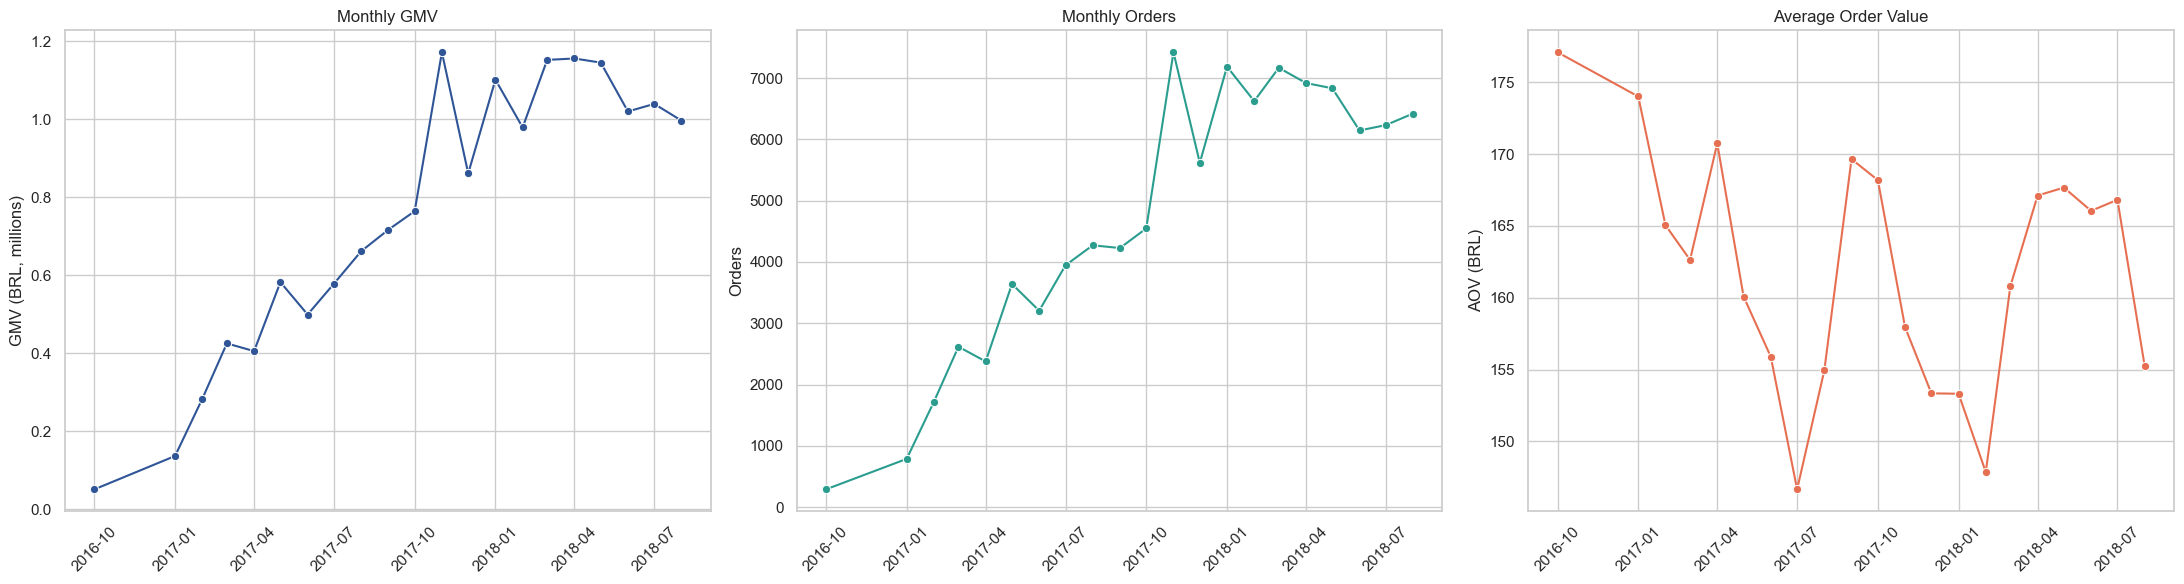

In [81]:
from matplotlib.ticker import FuncFormatter

growth_metrics_plot = (
    monthly_metrics_full
    .query("orders >= 100")
    .copy()
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(22, 6),
)

sns.lineplot(
    data=growth_metrics_plot,
    x="purchase_month",
    y="gmv",
    marker="o",
    color=PALETTE["gmv"],
    ax=axes[0],
)

axes[0].set_title("Monthly GMV")
axes[0].set_xlabel("")
axes[0].set_ylabel("GMV (BRL, millions)")
axes[0].yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{x / 1_000_000:.1f}")
)
axes[0].tick_params(axis="x", rotation=45)

sns.lineplot(
    data=growth_metrics_plot,
    x="purchase_month",
    y="orders",
    marker="o",
    color=PALETTE["orders"],
    ax=axes[1],
)

axes[1].set_title("Monthly Orders")
axes[1].set_xlabel("")
axes[1].set_ylabel("Orders")
axes[1].tick_params(axis="x", rotation=45)

sns.lineplot(
    data=growth_metrics_plot,
    x="purchase_month",
    y="aov",
    marker="o",
    color=PALETTE["aov"],
    ax=axes[2],
)

axes[2].set_title("Average Order Value")
axes[2].set_xlabel("")
axes[2].set_ylabel("AOV (BRL)")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()

plt.savefig(
    IMAGE_DIR / "monthly_growth_kpis.png",
    bbox_inches="tight",
    dpi=300,
)

plt.show()

peak_month = growth_metrics_plot.loc[
    growth_metrics_plot["gmv"].idxmax()
]

start_month = growth_metrics_plot.iloc[0]
end_month = growth_metrics_plot.iloc[-1]

gmv_growth = (
    end_month["gmv"] / start_month["gmv"] - 1
)

> Interpretation
> * GMV and order volume grow strongly after the early marketplace period, showing clear expansion in transaction activity.
> * Average order value remains relatively stable compared with GMV and orders, suggesting that growth is driven more by transaction volume than by larger baskets.
> * Filtering out very low-volume months makes the trend easier to interpret and avoids giving too much weight to sparse launch-period observations.
> * This points to customer acquisition and order volume as the main growth drivers to investigate in the next sections.

## 4.2 Customer Acquisition vs Repeat Behavior

After reviewing marketplace growth, the next step is to understand whether that growth is supported by repeat purchasing behavior.

This analysis compares new customer acquisition with returning customer activity over time and tracks the share of monthly orders coming from repeat purchases. The goal is to evaluate whether marketplace expansion depends mainly on acquiring new customers or whether returning customers also play a meaningful role.

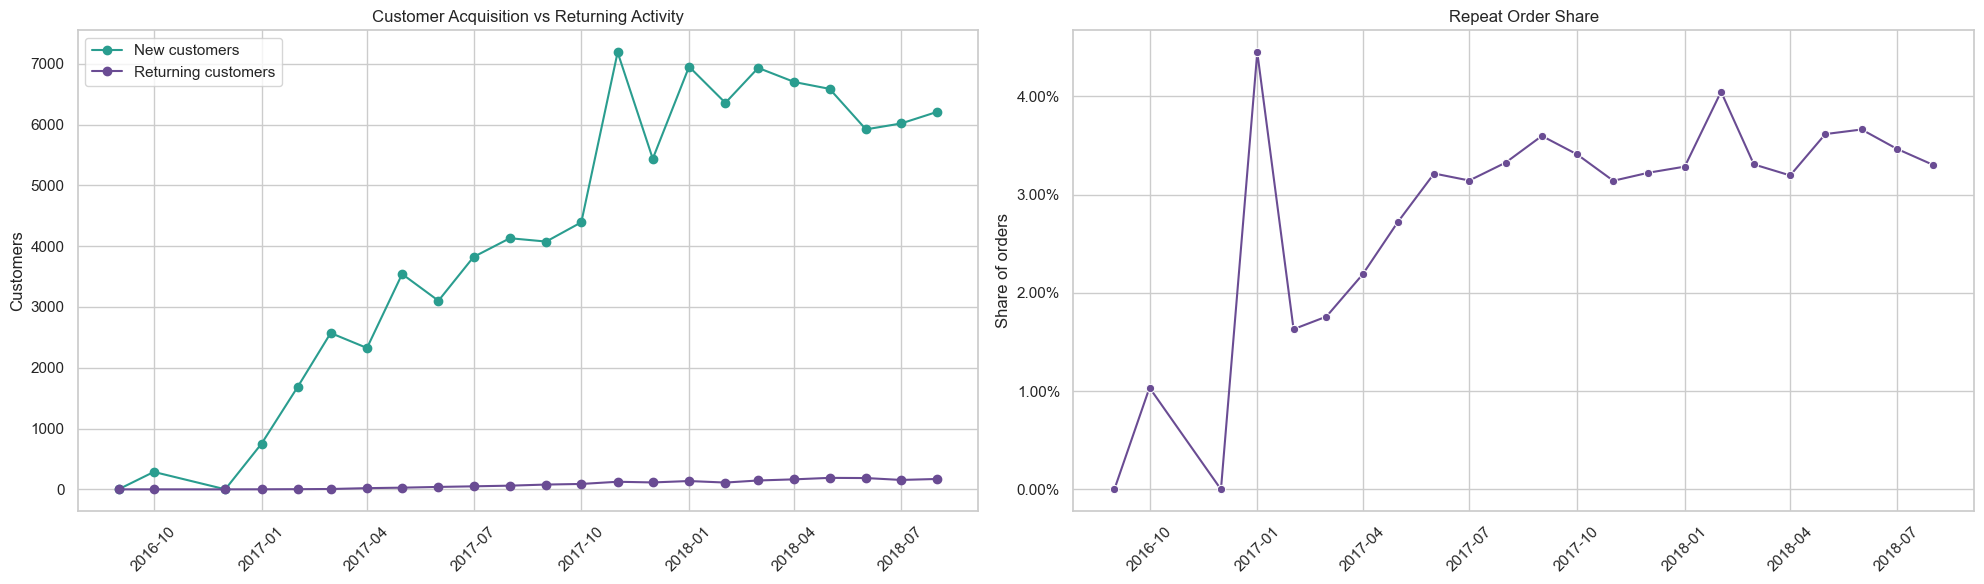

In [82]:
from matplotlib.ticker import PercentFormatter

monthly_customer_mix_query = """
SELECT
    purchase_month,
    active_customers,
    new_customers,
    returning_customer_proxy,
    repeat_orders,
    total_orders,
    repeat_order_share
FROM vw_monthly_customer_mix
ORDER BY purchase_month;
"""

with engine.connect() as conn:
    monthly_customer_mix = pd.read_sql(
        text(monthly_customer_mix_query),
        conn,
    )

monthly_customer_mix_plot = (
    monthly_customer_mix[
        monthly_customer_mix["purchase_month"]
        < monthly_customer_mix["purchase_month"].max()
    ]
    .copy()
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(20, 6),
)

axes[0].plot(
    monthly_customer_mix_plot["purchase_month"],
    monthly_customer_mix_plot["new_customers"],
    marker="o",
    label="New customers",
    color=PALETTE["orders"],
)

axes[0].plot(
    monthly_customer_mix_plot["purchase_month"],
    monthly_customer_mix_plot["returning_customer_proxy"],
    marker="o",
    label="Returning customers",
    color=PALETTE["retention"],
)

axes[0].set_title("Customer Acquisition vs Returning Activity")
axes[0].set_xlabel("")
axes[0].set_ylabel("Customers")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend()

sns.lineplot(
    data=monthly_customer_mix_plot,
    x="purchase_month",
    y="repeat_order_share",
    marker="o",
    color=PALETTE["retention"],
    ax=axes[1],
)

axes[1].set_title("Repeat Order Share")
axes[1].set_xlabel("")
axes[1].set_ylabel("Share of orders")
axes[1].yaxis.set_major_formatter(
    PercentFormatter(xmax=1)
)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()

plt.savefig(
    IMAGE_DIR / "customer_acquisition_vs_repeat_behavior.png",
    bbox_inches="tight",
    dpi=300,
)

plt.show()

repeat_rate_query = """
SELECT
    AVG(repeat_customer::numeric) AS repeat_rate
FROM vw_customer_level;
"""

with engine.connect() as conn:
    repeat_rate_result = pd.read_sql(
        text(repeat_rate_query),
        conn,
    )

repeat_rate = repeat_rate_result.loc[0, "repeat_rate"]

avg_repeat_share = (
    monthly_customer_mix_plot["repeat_order_share"]
    .mean()
)

> Interpretation
> * Marketplace growth is mainly supported by new customer acquisition rather than by a large returning-customer base.
> * Returning customer activity remains much smaller than first-time customer activity throughout the observed period.
> * Repeat order share stays low over time, suggesting that growth came more from scaling transaction volume than from materially changing repeat purchasing behavior.
> * This makes retention one of the most important structural weaknesses to investigate in the next sections.

## 4.3 Category Scale, Concentration, and Satisfaction

Marketplace growth is not distributed evenly across product categories.

This analysis looks at which categories generate the most GMV and how scale relates to customer satisfaction and freight intensity. The goal is to identify categories that are commercially important, but may also carry more operational complexity.

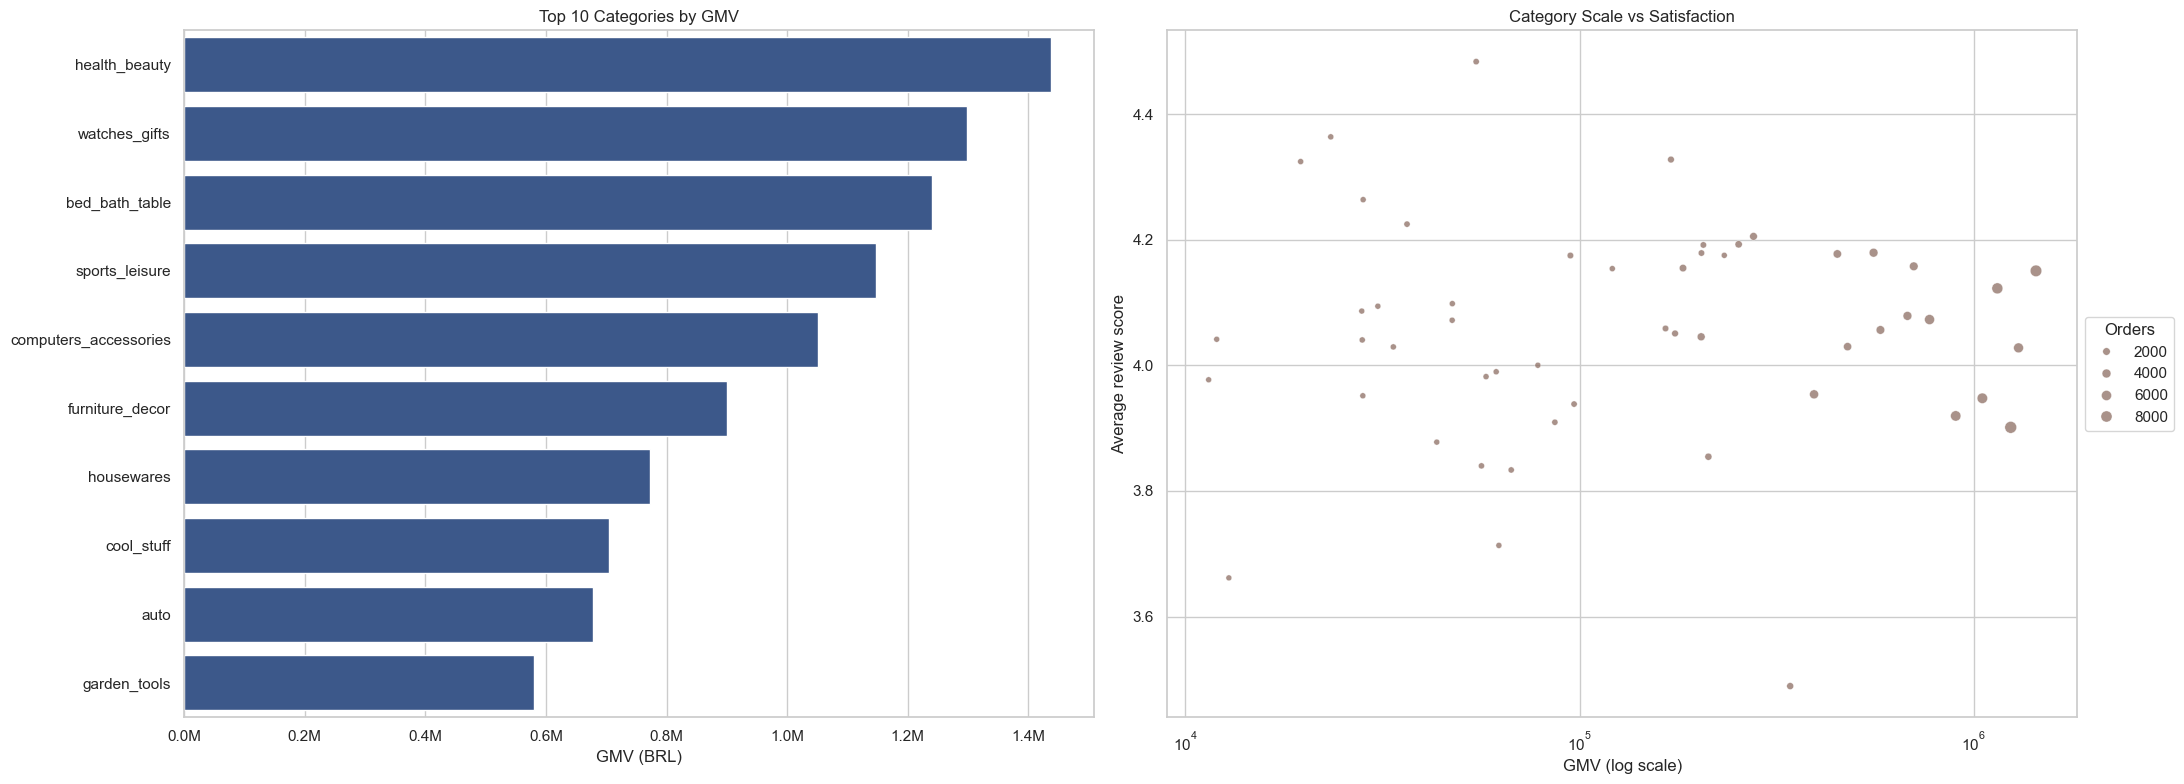

,product_category_name_english,gmv,orders,avg_review,avg_freight_share
0,health_beauty,"1,437,665.78",8800,4.15,0.13
1,watches_gifts,"1,298,292.47",5604,4.03,0.08
2,bed_bath_table,"1,240,386.13",9399,3.90,0.16
3,sports_leisure,"1,147,244.63",7673,4.12,0.15
4,computers_accessories,"1,050,941.58",6654,3.95,0.14
5,furniture_decor,"899,626.04",6425,3.92,0.19
6,housewares,"772,035.14",5847,4.07,0.19
7,cool_stuff,"704,086.24",3616,4.16,0.12
8,auto,"678,606.64",3872,4.08,0.14
9,garden_tools,"579,525.20",3505,4.06,0.17


In [83]:
category_summary_query = """
SELECT
    product_category_name_english,
    gmv,
    orders,
    avg_review,
    avg_freight_share
FROM vw_category_summary
ORDER BY gmv DESC;
"""

with engine.connect() as conn:
    category_summary = pd.read_sql(
        text(category_summary_query),
        conn,
    )

top_categories = category_summary.head(10).copy()

review_cutoff = category_summary["avg_review"].median()
gmv_cutoff = category_summary["gmv"].quantile(0.75)

fix_categories = (
    category_summary[
        (category_summary["gmv"] >= gmv_cutoff)
        & (category_summary["avg_review"] < review_cutoff)
    ]
    .sort_values("gmv", ascending=False)
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(22, 8),
)

sns.barplot(
    data=top_categories,
    y="product_category_name_english",
    x="gmv",
    color=PALETTE["gmv"],
    ax=axes[0],
)

axes[0].set_title("Top 10 Categories by GMV")
axes[0].set_xlabel("GMV (BRL)")
axes[0].set_ylabel("")
axes[0].xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{x / 1_000_000:.1f}M")
)

sns.scatterplot(
    data=category_summary.query("orders >= 100"),
    x="gmv",
    y="avg_review",
    size="orders",
    color=PALETTE["logistics"],
    alpha=0.75,
    ax=axes[1],
)

axes[1].set_xscale("log")
axes[1].set_title("Category Scale vs Satisfaction")
axes[1].set_xlabel("GMV (log scale)")
axes[1].set_ylabel("Average review score")

axes[1].legend(
    title="Orders",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
)

plt.tight_layout()

plt.savefig(
    IMAGE_DIR / "category_scale_satisfaction.png",
    bbox_inches="tight",
    dpi=300,
)

plt.show()

display(
    category_summary[
        [
            "product_category_name_english",
            "gmv",
            "orders",
            "avg_review",
            "avg_freight_share",
        ]
    ]
    .head(10)
    .reset_index(drop=True)
    .round(2)
)

> Interpretation
> * GMV is concentrated among a relatively small group of large categories, led by **health_beauty**, **watches_gifts**, and **bed_bath_table**.
> * The scatterplot shows that commercial scale does not always translate into stronger customer satisfaction.
> * Some high-GMV categories combine large order volume with lower review scores or higher freight share, suggesting more operational complexity.
> * This reinforces the importance of evaluating category performance beyond revenue alone, especially when logistics and customer experience may affect long-term marketplace quality.

## 4.4 Seller Concentration and Operational Quality

Marketplace growth also depends on how value and operational quality are distributed across sellers.

This analysis evaluates seller concentration, marketplace dependency on top-performing merchants, and whether high seller scale is consistently associated with strong customer satisfaction.

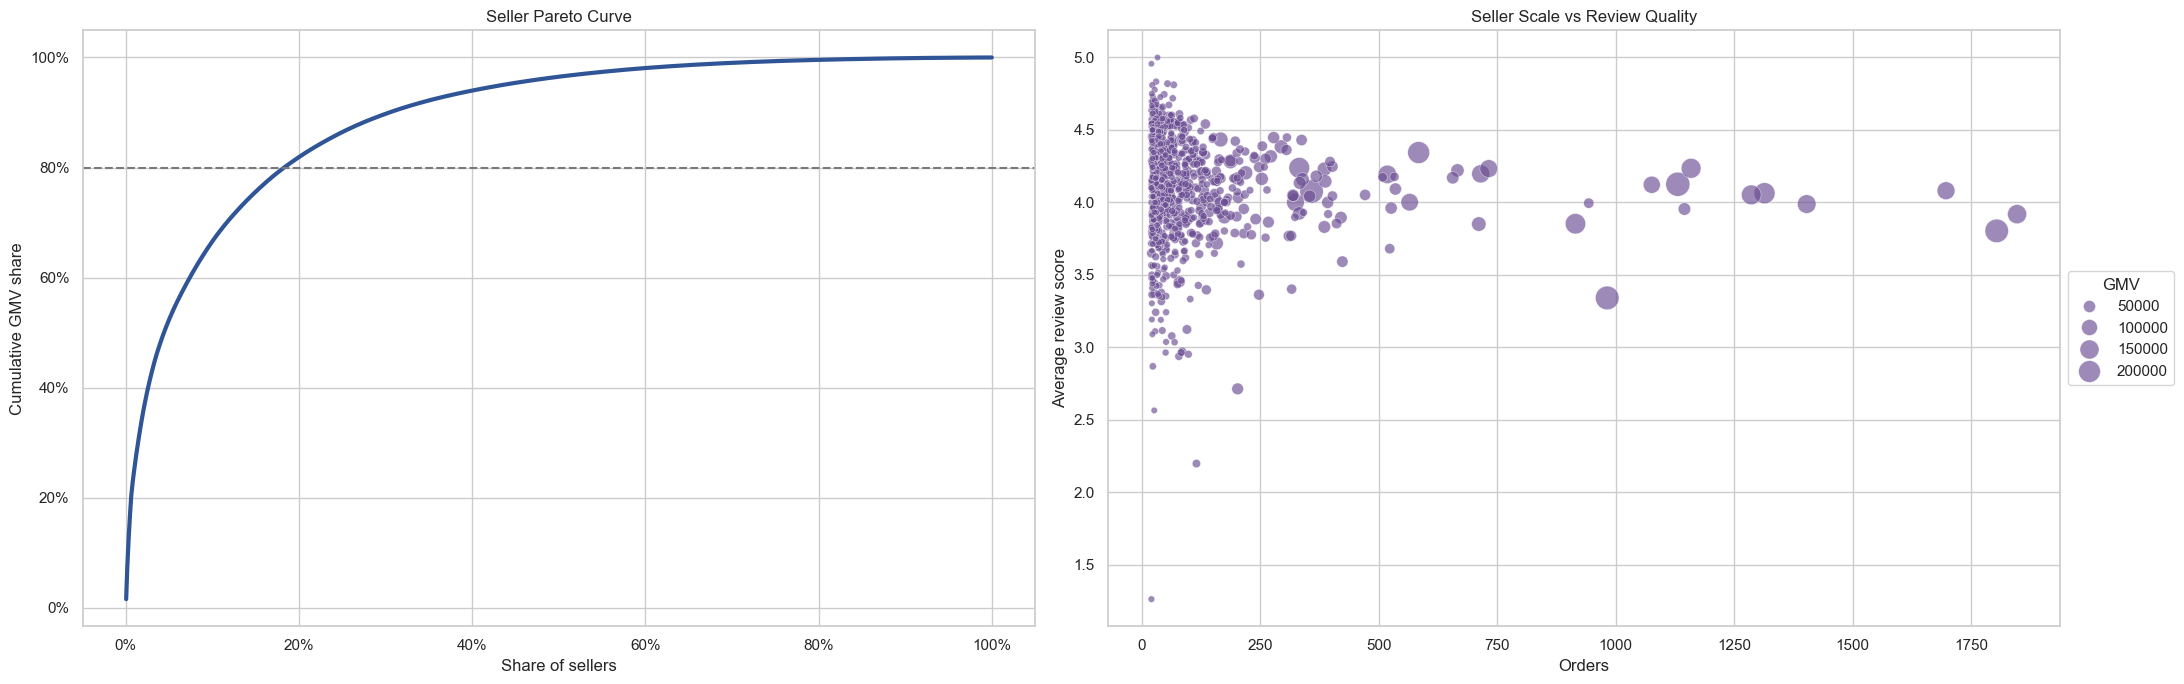

,seller_id,gmv,orders,avg_review,late_delivery_rate
0,1ca7077d890b907f89be8c954a02686a,"15,001.43",115,2.20,0.18
1,2eb70248d66e0e3ef83659f71b244378,"45,860.10",202,2.71,0.13
2,b2479f944e1b90cf8a5de1bbfde284d6,"6,943.54",102,3.33,0.15
3,7c67e1448b00f6e969d365cea6b010ab,"239,536.44",982,3.34,0.10
4,88460e8ebdecbfecb5f9601833981930,"36,377.40",247,3.36,0.20


In [84]:
seller_summary_query = """
SELECT
    seller_id,
    gmv,
    orders,
    customers,
    avg_review,
    late_delivery_rate,
    cumulative_gmv_share
FROM vw_seller_summary
ORDER BY gmv DESC;
"""

with engine.connect() as conn:
    seller_summary = pd.read_sql(
        text(seller_summary_query),
        conn,
    )

seller_top10_share = (
    seller_summary.head(10)["gmv"].sum()
    / seller_summary["gmv"].sum()
)

seller_top50_share = (
    seller_summary.head(50)["gmv"].sum()
    / seller_summary["gmv"].sum()
)

risky_sellers = (
    seller_summary[seller_summary["orders"] >= 100]
    .sort_values(
        ["avg_review", "gmv"],
        ascending=[True, False],
    )
    .head(10)
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(22, 7),
)

seller_curve = seller_summary.reset_index(drop=True).copy()

seller_curve["seller_percentile"] = (
    (seller_curve.index + 1)
    / len(seller_curve)
)

axes[0].plot(
    seller_curve["seller_percentile"],
    seller_curve["cumulative_gmv_share"],
    linewidth=3,
    color=PALETTE["gmv"],
)

axes[0].axhline(
    0.8,
    linestyle="--",
    color=PALETTE["neutral"],
)

axes[0].set_title("Seller Pareto Curve")
axes[0].set_xlabel("Share of sellers")
axes[0].set_ylabel("Cumulative GMV share")
axes[0].yaxis.set_major_formatter(
    PercentFormatter(xmax=1)
)
axes[0].xaxis.set_major_formatter(
    PercentFormatter(xmax=1)
)

sns.scatterplot(
    data=seller_summary[
        seller_summary["orders"] >= 20
    ],
    x="orders",
    y="avg_review",
    size="gmv",
    sizes=(20, 300),
    color=PALETTE["retention"],
    alpha=0.65,
    ax=axes[1],
)

axes[1].set_title("Seller Scale vs Review Quality")
axes[1].set_xlabel("Orders")
axes[1].set_ylabel("Average review score")

axes[1].legend(
    title="GMV",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
)

plt.tight_layout()

plt.savefig(
    IMAGE_DIR / "seller_concentration_quality.png",
    bbox_inches="tight",
    dpi=300,
)

plt.show()

display(
    risky_sellers[
        [
            "seller_id",
            "gmv",
            "orders",
            "avg_review",
            "late_delivery_rate",
        ]
    ]
    .head(5)
    .reset_index(drop=True)
    .round(2)
)

In [85]:
print(f"Top 10 seller GMV share: {seller_top10_share:.1%}")
print(f"Top 50 seller GMV share: {seller_top50_share:.1%}")

Top 10 seller GMV share: 12.9%
Top 50 seller GMV share: 32.4%


> Interpretation
> * Seller GMV is meaningfully concentrated, with the top 10 sellers generating about 12.9% of total GMV and the top 50 accounting for about 32.4%.
> * The Pareto curve shows that marketplace value depends on a relatively small group of high-performing merchants.
> * Seller scale does not always translate into stronger customer satisfaction, since some sellers with relevant order volume still show weaker review performance.
> * This suggests that seller management should balance commercial importance with operational quality, especially for merchants that generate both high GMV and customer experience risk.

## 4.5 Logistics Performance and Customer Satisfaction

Customer experience in marketplaces is strongly influenced by fulfillment quality and delivery reliability.

This analysis examines how review scores vary across delivery timeliness and shipping distance. The goal is to understand whether logistics friction is associated with lower customer satisfaction and where operational issues may affect the marketplace experience.

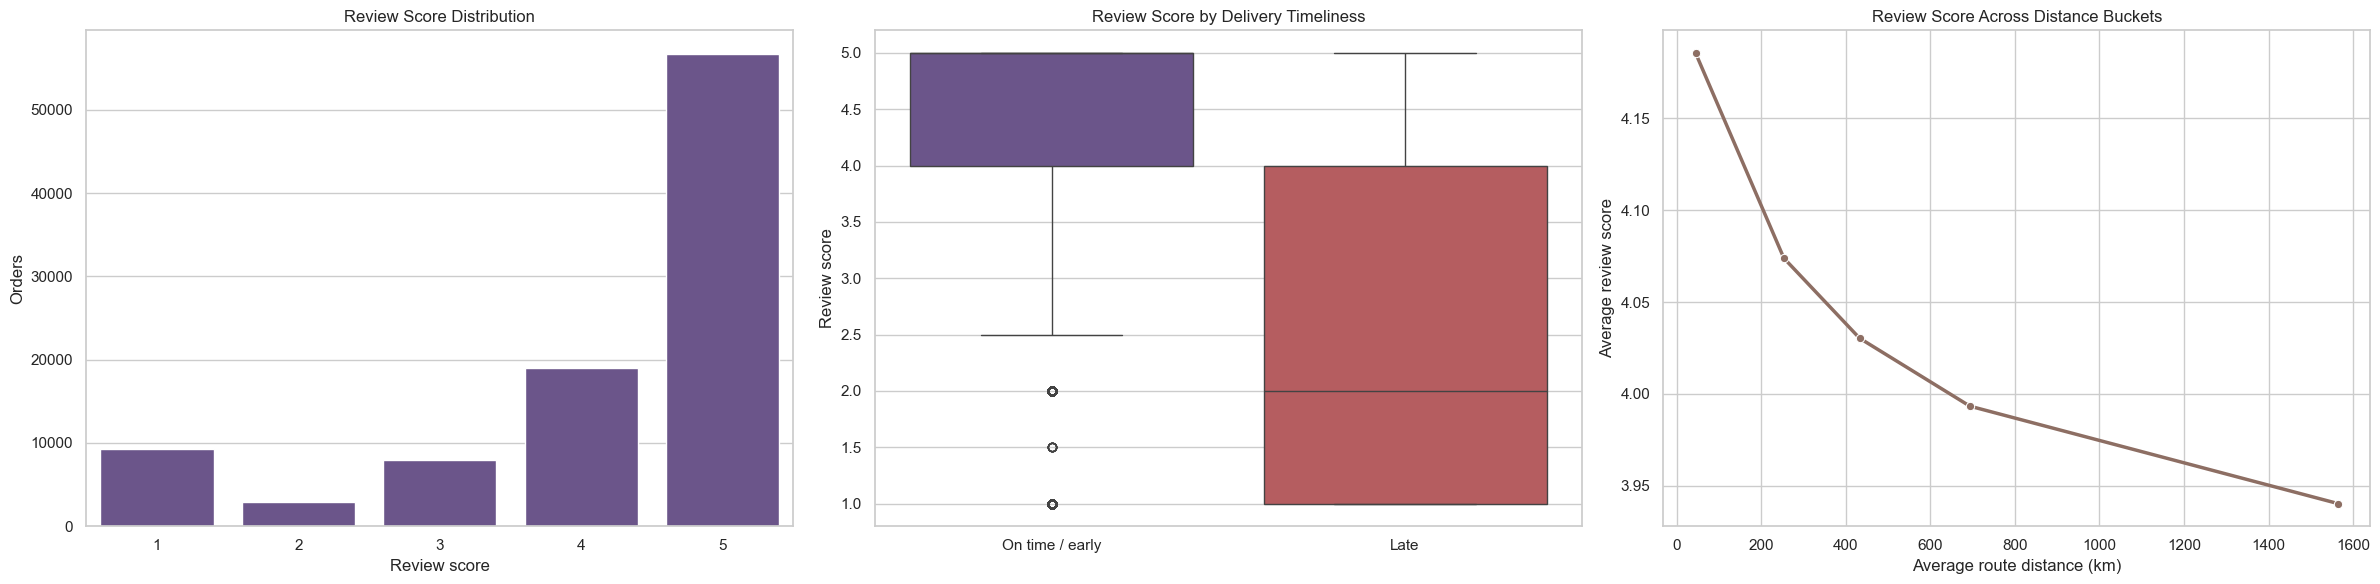

In [86]:
delivered_orders_query = """
SELECT
    order_id,
    review_score,
    is_late_delivery,
    avg_distance_km
FROM vw_delivered_orders
WHERE review_score IS NOT NULL;
"""

with engine.connect() as conn:
    delivered_orders = pd.read_sql(
        text(delivered_orders_query),
        conn,
    )

delivered_orders["review_score_rounded"] = (
    delivered_orders["review_score"]
    .round()
    .clip(1, 5)
    .astype(int)
)

review_by_lateness = delivered_orders.assign(
    delivery_status=np.where(
        delivered_orders["is_late_delivery"] == 1,
        "Late",
        "On time / early",
    )
)

distance_summary_query = """
SELECT
    distance_bucket,
    avg_distance_km,
    avg_freight,
    avg_review
FROM vw_distance_summary
ORDER BY distance_bucket;
"""

with engine.connect() as conn:
    distance_summary = pd.read_sql(
        text(distance_summary_query),
        conn,
    )

fig, axes = plt.subplots(
    1,
    3,
    figsize=(24, 6),
)

sns.countplot(
    data=delivered_orders,
    x="review_score_rounded",
    order=[1, 2, 3, 4, 5],
    color=PALETTE["retention"],
    ax=axes[0],
)

axes[0].set_title("Review Score Distribution")
axes[0].set_xlabel("Review score")
axes[0].set_ylabel("Orders")

sns.boxplot(
    data=review_by_lateness,
    x="delivery_status",
    y="review_score",
    palette={
        "On time / early": PALETTE["retention"],
        "Late": PALETTE["negative"],
    },
    ax=axes[1],
)

axes[1].set_title("Review Score by Delivery Timeliness")
axes[1].set_xlabel("")
axes[1].set_ylabel("Review score")

sns.lineplot(
    data=distance_summary,
    x="avg_distance_km",
    y="avg_review",
    marker="o",
    linewidth=2.5,
    color=PALETTE["logistics"],
    ax=axes[2],
)

axes[2].set_title("Review Score Across Distance Buckets")
axes[2].set_xlabel("Average route distance (km)")
axes[2].set_ylabel("Average review score")

plt.tight_layout()

plt.savefig(
    IMAGE_DIR / "logistics_satisfaction_patterns.png",
    bbox_inches="tight",
    dpi=300,
)

plt.show()

review_on_time = review_by_lateness.loc[
    review_by_lateness["delivery_status"] == "On time / early",
    "review_score",
].mean()

review_late = review_by_lateness.loc[
    review_by_lateness["delivery_status"] == "Late",
    "review_score",
].mean()


> Interpretation
> * Review scores are heavily concentrated at the high end, suggesting that many delivered orders received positive customer feedback.
> * Late deliveries stand out as a major source of dissatisfaction, with average review scores dropping sharply compared with on-time or early deliveries.
> * Longer customer-seller distances are associated with gradually lower review scores, suggesting that logistics complexity may weaken customer experience.
> * Delivery reliability should be treated as a strategic operational KPI, especially because fulfillment friction can affect satisfaction, trust, and future purchase behavior.

## 4.6 Regional GMV and Route Economics

Marketplace performance also depends on where demand is concentrated and how orders move across regions.

This analysis compares GMV concentration by customer state and evaluates how cross-state and same-state routes differ in freight cost and customer satisfaction. The goal is to understand whether geographic reach creates additional logistics pressure for the marketplace.

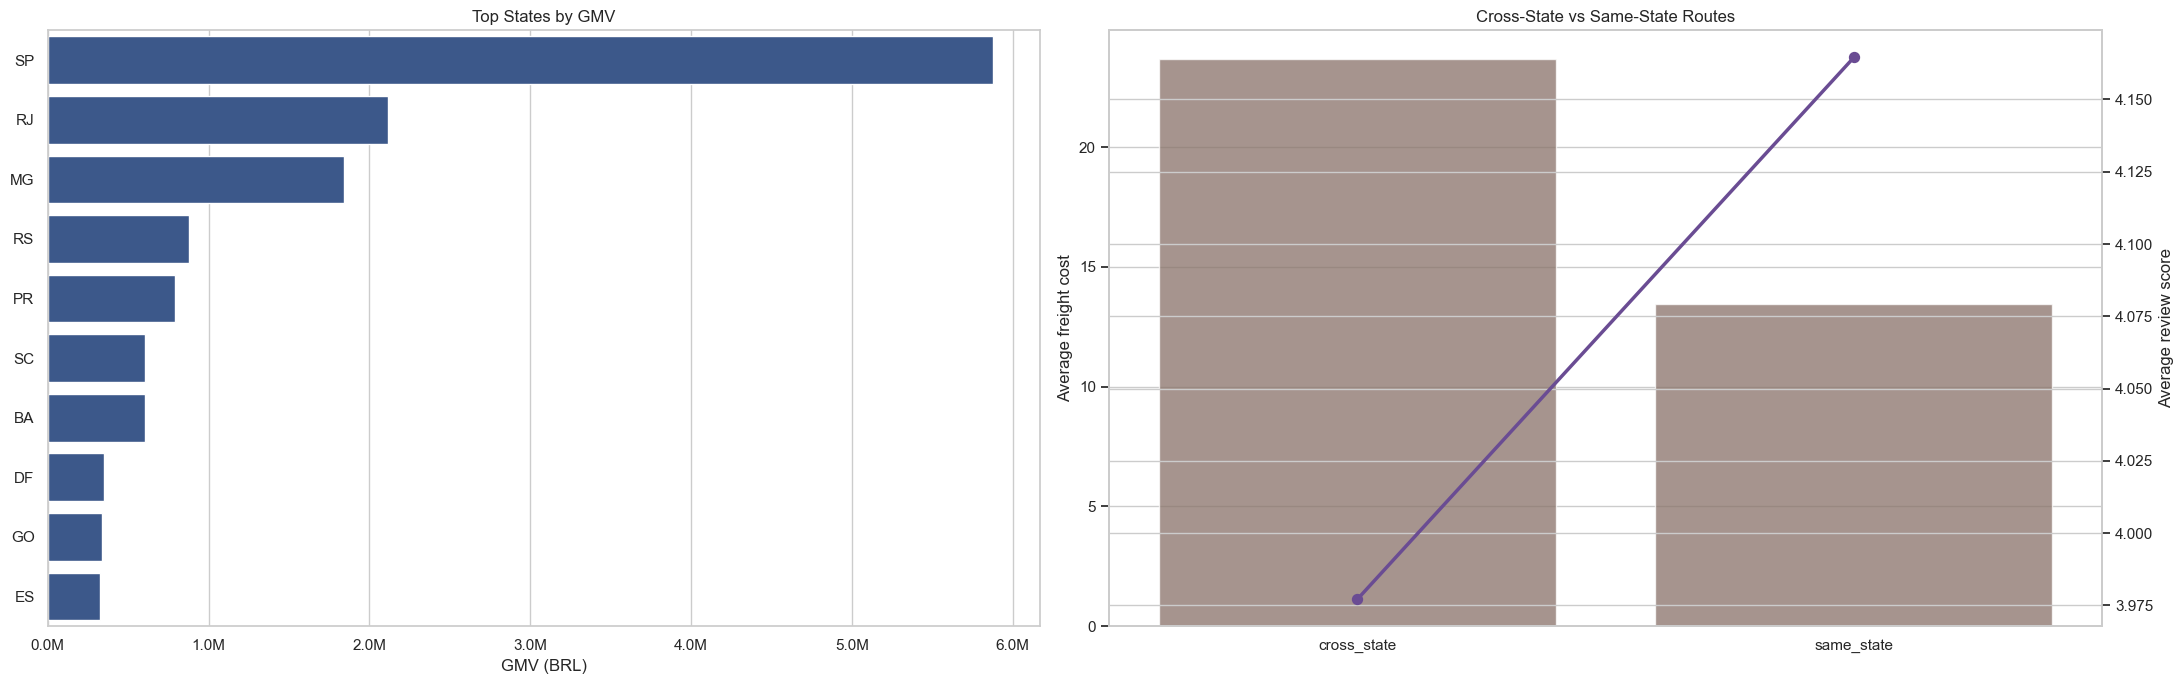

In [87]:
state_summary_query = """
SELECT
    customer_state,
    gmv,
    orders,
    customers,
    avg_review,
    avg_order_value
FROM vw_state_summary
ORDER BY gmv DESC;
"""

with engine.connect() as conn:
    state_summary = pd.read_sql(
        text(state_summary_query),
        conn,
    )

route_summary_query = """
SELECT
    route_type,
    items,
    gmv,
    avg_freight,
    avg_review,
    gmv_share
FROM vw_route_summary
ORDER BY gmv DESC;
"""

with engine.connect() as conn:
    route_summary = pd.read_sql(
        text(route_summary_query),
        conn,
    )

top_states = state_summary.head(10).copy()

fig, axes = plt.subplots(
    1,
    2,
    figsize=(22, 7),
)

sns.barplot(
    data=top_states,
    x="gmv",
    y="customer_state",
    color=PALETTE["gmv"],
    ax=axes[0],
)

axes[0].set_title("Top States by GMV")
axes[0].set_xlabel("GMV (BRL)")
axes[0].set_ylabel("")
axes[0].xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{x / 1_000_000:.1f}M")
)

sns.barplot(
    data=route_summary,
    x="route_type",
    y="avg_freight",
    color=PALETTE["logistics"],
    alpha=0.75,
    ax=axes[1],
)

axes[1].set_ylabel("Average freight cost")
axes[1].set_xlabel("")

ax2 = axes[1].twinx()

sns.pointplot(
    data=route_summary,
    x="route_type",
    y="avg_review",
    color=PALETTE["retention"],
    marker="o",
    linewidth=2.5,
    ax=ax2,
)

ax2.set_ylabel("Average review score")

axes[1].set_title("Cross-State vs Same-State Routes")

plt.tight_layout()

plt.savefig(
    IMAGE_DIR / "regional_gmv_route_economics.png",
    bbox_inches="tight",
    dpi=300,
)

plt.show()

top_state = top_states.iloc[0]

cross_state_row = route_summary.loc[
    route_summary["route_type"] == "cross_state"
].iloc[0]

> Interpretation
> * Marketplace GMV is strongly concentrated in a few customer states, with **SP** standing out as the largest demand market.
> * Cross-state routes represent most marketplace GMV and carry higher average freight costs than same-state routes.
> * Same-state routes show slightly stronger review scores, suggesting that shorter or more localized logistics flows may offer a smoother customer experience.
> * These patterns suggest that regional seller density and inventory allocation could be important levers for improving logistics efficiency and customer satisfaction.

## 4.7 Cohort Retention Over Time

To better understand customer retention, this analysis tracks monthly cohorts based on each customer's first observed purchase month.

The heatmap focuses on post-acquisition months, excluding month 0 because it always represents 100% of the cohort. This makes it easier to evaluate whether customers continue purchasing after their first order and how quickly retention decays over time.

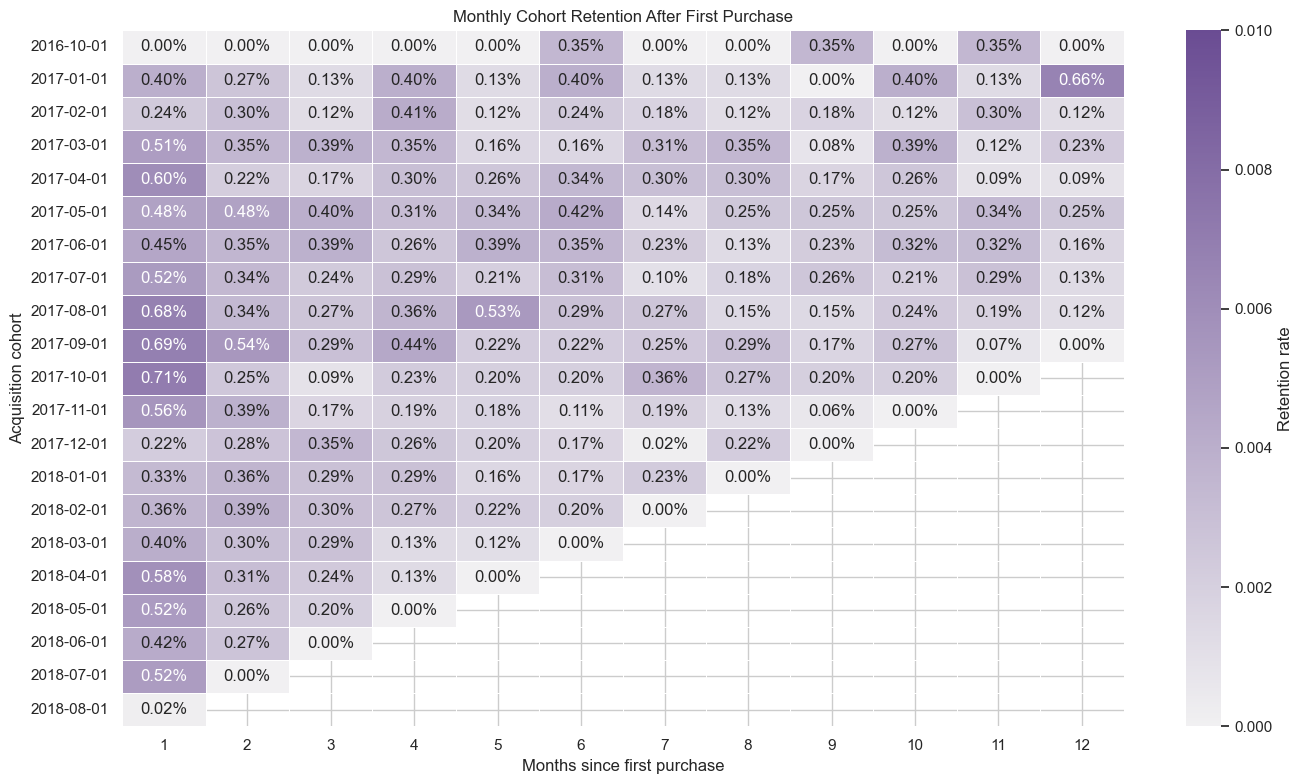

In [88]:
cohort_heatmap = (
    cohort_matrix
    .iloc[:, 1:13]
    .copy()
)

cohort_heatmap.index = (
    cohort_heatmap.index.astype(str)
)

cohort_annot = cohort_heatmap.map(
    lambda x: f"{x:.2%}" if pd.notna(x) else ""
)

retention_cmap = sns.light_palette(
    PALETTE["retention"],
    as_cmap=True,
)

plt.figure(figsize=(14, 8))

sns.heatmap(
    cohort_heatmap,
    annot=cohort_annot,
    fmt="",
    cmap=retention_cmap,
    vmin=0,
    vmax=0.01,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={
        "label": "Retention rate"
    },
)

plt.title("Monthly Cohort Retention After First Purchase")
plt.xlabel("Months since first purchase")
plt.ylabel("Acquisition cohort")

plt.tight_layout()

plt.savefig(
    IMAGE_DIR / "cohort_retention.png",
    bbox_inches="tight",
    dpi=300,
)

plt.show()

avg_retention_m1 = cohort_matrix[1].mean()
avg_retention_m3 = cohort_matrix[3].mean()

In [89]:
cohort_retention_filtered = cohort_retention.query("cohort_size >= 100")

avg_retention_m1 = (
    cohort_retention_filtered
    .query("cohort_index == 1")["retention"]
    .mean()
)

avg_retention_m3 = (
    cohort_retention_filtered
    .query("cohort_index == 3")["retention"]
    .mean()
)

print(f"Average month-1 retention: {avg_retention_m1:.2%}")
print(f"Average month-3 retention: {avg_retention_m3:.2%}")

Average month-1 retention: 0.44%
Average month-3 retention: 0.23%


> Interpretation
> * Retention after the first observed purchase is extremely low across almost all cohorts.
> * Average month-1 retention is approximately **0.44%**, showing that only a very small share of customers return shortly after their first purchase.
> * By month 3, average retention falls to approximately **0.23%**, suggesting limited long-term purchasing continuity in the observed marketplace data.
> * The consistency of this pattern across acquisition cohorts suggests that weak repeat purchasing is a structural marketplace issue rather than a temporary seasonal effect.

# 5. Customer Lifetime Value (LTV)

One of the most important challenges in this marketplace is the difficulty of generating repeat purchasing behavior. Most customers buy only once, which makes customer value highly dependent on the size and quality of each observed purchase.

This section starts with realized historical LTV, measured as the total GMV generated by each customer during the available dataset period. This creates a simple and reliable baseline before moving into more advanced customer value and retention-oriented analysis.

The goal is not to assume long-term customer value beyond the data, but to understand how customer value is distributed, how concentrated GMV is across customer segments, and which groups may deserve more strategic attention.

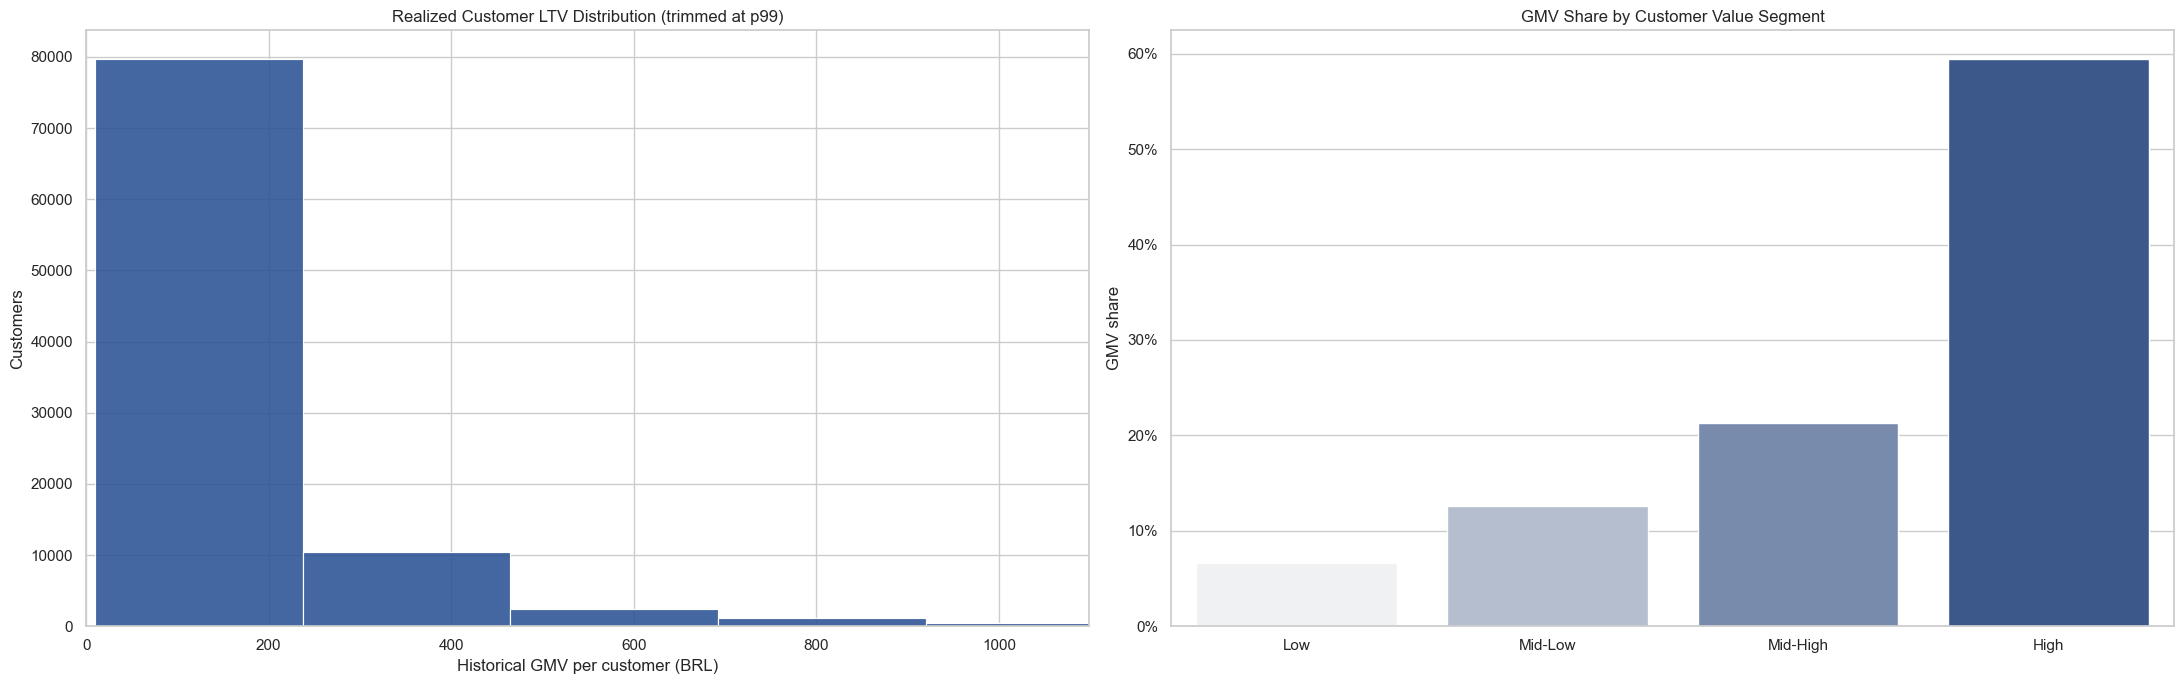

,value_segment,customers,gmv,avg_orders,avg_review,avg_recency_days,gmv_share
0,Low,23746,"1,036,132.48",1.00,4.20,245.44,0.07
1,Mid-Low,23746,"1,986,695.05",1.01,4.14,246.62,0.13
2,Mid-High,23746,"3,354,004.82",1.03,4.12,239.11,0.21
3,High,23745,"9,358,694.68",1.09,4.00,241.14,0.59


In [90]:
from matplotlib.ticker import PercentFormatter

customer_level_query = """
SELECT
    customer_unique_id,
    total_gmv,
    total_orders,
    avg_order_value,
    avg_review_score,
    avg_delivery_days,
    late_delivery_rate,
    recency_days,
    tenure_days,
    purchase_frequency_per_month,
    realized_ltv,
    repeat_customer,
    value_segment
FROM vw_customer_level;
"""

with engine.connect() as conn:
    customer_level = pd.read_sql(
        text(customer_level_query),
        conn,
    )

segment_order = [
    "Low",
    "Mid-Low",
    "Mid-High",
    "High",
]

customer_level["value_segment"] = pd.Categorical(
    customer_level["value_segment"],
    categories=segment_order,
    ordered=True,
)

ltv_segment_summary = (
    customer_level
    .groupby(
        "value_segment",
        observed=False,
        as_index=False,
    )
    .agg(
        customers=("customer_unique_id", "nunique"),
        gmv=("realized_ltv", "sum"),
        avg_orders=("total_orders", "mean"),
        avg_review=("avg_review_score", "mean"),
        avg_recency_days=("recency_days", "mean"),
    )
)

ltv_segment_summary["gmv_share"] = (
    ltv_segment_summary["gmv"]
    / ltv_segment_summary["gmv"].sum()
)

value_segment_colors = sns.light_palette(
    PALETTE["gmv"],
    n_colors=4,
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(22, 7),
)

sns.histplot(
    customer_level["realized_ltv"],
    bins=60,
    alpha=0.9,
    color=PALETTE["gmv"],
    ax=axes[0],
)

axes[0].set_xlim(
    0,
    customer_level["realized_ltv"].quantile(0.99),
)

axes[0].set_title(
    "Realized Customer LTV Distribution (trimmed at p99)"
)

axes[0].set_xlabel(
    "Historical GMV per customer (BRL)"
)

axes[0].set_ylabel("Customers")

sns.barplot(
    data=ltv_segment_summary,
    x="value_segment",
    y="gmv_share",
    order=segment_order,
    palette=value_segment_colors,
    ax=axes[1],
)

axes[1].set_title("GMV Share by Customer Value Segment")
axes[1].set_xlabel("")
axes[1].set_ylabel("GMV share")
axes[1].yaxis.set_major_formatter(
    PercentFormatter(1)
)

plt.tight_layout()

plt.savefig(
    IMAGE_DIR / "customer_ltv_distribution_segments.png",
    bbox_inches="tight",
    dpi=300,
)

plt.show()

display(
    ltv_segment_summary
    .round(2)
)

median_ltv = (
    customer_level["realized_ltv"].median()
)

p90_ltv = (
    customer_level["realized_ltv"].quantile(0.90)
)

repeat_rate = (
    customer_level["repeat_customer"].mean()
)

high_segment_share = ltv_segment_summary.loc[
    ltv_segment_summary["value_segment"] == "High",
    "gmv_share",
].iat[0]

> Interpretation
> * Realized customer LTV is strongly right-skewed, with most customers generating relatively low historical GMV during the observed period.
> * Customer value is highly concentrated: the **High** value segment accounts for approximately **59%** of total marketplace GMV.
> * Average order counts remain close across segments, which suggests that value differences are driven more by basket size and cumulative GMV than by high purchase frequency alone.
> * This concentration supports the need for differentiated retention, CRM, and personalization strategies focused on the most valuable customer groups.

## 5.1 Probabilistic Customer Lifetime Modeling

To extend the customer value analysis, this section applies probabilistic lifetime modeling using BG/NBD and Gamma-Gamma models.

Because repeat purchasing is very limited in this marketplace, the goal is not to produce precise long-term revenue forecasts for every customer. Instead, the model is used as an exploratory way to estimate relative purchase propensity and value potential among customers with observed repeat behavior.

This helps identify whether a small subset of customers may deserve more attention from CRM, retention, and personalization strategies.

In [91]:
from lifetimes import (
    BetaGeoFitter,
    GammaGammaFitter,
)

from lifetimes.utils import (
    summary_data_from_transaction_data,
)

ltv_transactions_query = """
SELECT
    customer_unique_id,
    order_purchase_timestamp,
    order_gmv
FROM vw_delivered_orders
WHERE
    customer_unique_id IS NOT NULL
    AND order_purchase_timestamp IS NOT NULL
    AND order_gmv IS NOT NULL
    AND order_gmv > 0;
"""

with engine.connect() as conn:
    ltv_transactions = pd.read_sql(
        text(ltv_transactions_query),
        conn,
    )

lifetimes_summary = summary_data_from_transaction_data(
    transactions=ltv_transactions,
    customer_id_col="customer_unique_id",
    datetime_col="order_purchase_timestamp",
    monetary_value_col="order_gmv",
    observation_period_end=ltv_transactions[
        "order_purchase_timestamp"
    ].max(),
    freq="D",
)

bgf = BetaGeoFitter(
    penalizer_coef=0.01,
)

bgf.fit(
    lifetimes_summary["frequency"],
    lifetimes_summary["recency"],
    lifetimes_summary["T"],
)

ggf_input = lifetimes_summary[
    (lifetimes_summary["frequency"] > 0)
    & (lifetimes_summary["monetary_value"] > 0)
].copy()

ggf = GammaGammaFitter(
    penalizer_coef=0.01,
)

ggf.fit(
    ggf_input["frequency"],
    ggf_input["monetary_value"],
)

ggf_input["predicted_6m_purchases"] = (
    bgf.conditional_expected_number_of_purchases_up_to_time(
        180,
        ggf_input["frequency"],
        ggf_input["recency"],
        ggf_input["T"],
    )
)

ggf_input["predicted_6m_ltv"] = (
    ggf.customer_lifetime_value(
        bgf,
        ggf_input["frequency"],
        ggf_input["recency"],
        ggf_input["T"],
        ggf_input["monetary_value"],
        time=6,
        freq="D",
        discount_rate=0.01,
    )
)

display(
    ggf_input[
        [
            "frequency",
            "monetary_value",
            "predicted_6m_purchases",
            "predicted_6m_ltv",
        ]
    ]
    .describe()
    .round(2)
)

,frequency,monetary_value,predicted_6m_purchases,predicted_6m_ltv
count,"2,015.00","2,015.00","2,015.00","2,015.00"
mean,1.11,151.11,0.11,17.73
std,0.51,160.32,0.26,50.16
min,1.00,11.56,0.00,0.14
25%,1.00,62.68,0.02,2.34
50%,1.00,108.30,0.04,5.07
75%,1.00,179.22,0.07,11.45
max,14.00,"2,405.28",4.84,773.70


> Interpretation
> * The probabilistic LTV model is applied only to customers with observed repeat purchasing behavior, since Gamma-Gamma requires positive repeat frequency and monetary value.
> * Predicted future purchase activity remains low for most customers, with a median of only **0.04 expected purchases** over six months.
> * The predicted 6-month LTV is also highly concentrated: the median is approximately **BRL 5.07**, while the maximum reaches **BRL 773.70**.
> * Given the very low repeat purchase rate in the marketplace, these results should be interpreted as relative customer prioritization signals rather than precise long-term revenue forecasts.

# 6. Experimentation: Simulated A/B Test

The original marketplace data is observational, so it does not include a real randomized experiment. To explore how a retention initiative could be evaluated, this section simulates a customer-level A/B test under transparent assumptions.

The simulated experiment tests whether offering a 10% discount on a future purchase could increase customer conversion within 90 days and improve downstream marketplace value after accounting for discount costs.

The simulation follows a simplified experimental structure:

- **Unit of randomization:** customer
- **Population:** customers with a first observed purchase before a fixed cutoff
- **Treatment:** 10% discount incentive for a future purchase
- **Primary metric:** conversion within 90 days
- **Secondary metric:** GMV per user after discount effects

## 6.1 Experiment Design and Eligible Population

The first step defines the simulated experiment structure and selects the customers eligible for the retention campaign.

The population includes customers whose first observed purchase happened before a fixed cutoff date. From there, the analysis checks whether each customer placed another order within the following 90 days, creating the baseline conversion outcome for the simulated test.

In [92]:
experiment_cutoff = pd.Timestamp("2018-03-01")
experiment_window_days = 90

experiment_orders_query = """
SELECT
    order_id,
    customer_unique_id,
    order_purchase_timestamp,
    order_gmv,
    review_score,
    estimated_vs_actual_days
FROM vw_completed_orders
WHERE
    customer_unique_id IS NOT NULL
    AND order_purchase_timestamp IS NOT NULL
    AND order_gmv IS NOT NULL;
"""

with engine.connect() as conn:
    experiment_orders = pd.read_sql(
        text(experiment_orders_query),
        conn,
    )

first_orders = (
    experiment_orders
    .sort_values("order_purchase_timestamp")
    .groupby(
        "customer_unique_id",
        as_index=False,
    )
    .first()
)

eligible_customers = (
    first_orders[
        first_orders["order_purchase_timestamp"] < experiment_cutoff
    ]
    .copy()
)

future_orders = (
    experiment_orders[
        (experiment_orders["order_purchase_timestamp"] >= experiment_cutoff)
        & (
            experiment_orders["order_purchase_timestamp"]
            < experiment_cutoff + pd.Timedelta(days=experiment_window_days)
        )
    ]
    .copy()
)

future_customer_outcomes = (
    future_orders
    .groupby(
        "customer_unique_id",
        as_index=False,
    )
    .agg(
        future_orders=("order_id", "nunique"),
        future_gmv=("order_gmv", "sum"),
    )
)

experiment = (
    eligible_customers
    .merge(
        future_customer_outcomes,
        on="customer_unique_id",
        how="left",
    )
    .fillna(
        {
            "future_orders": 0,
            "future_gmv": 0,
        }
    )
)

experiment["baseline_conversion"] = (
    experiment["future_orders"] > 0
).astype(int)

display(
    experiment[
        [
            "customer_unique_id",
            "order_purchase_timestamp",
            "order_gmv",
            "future_orders",
            "future_gmv",
            "baseline_conversion",
        ]
    ]
    .head()
    .round(2)
)

,customer_unique_id,order_purchase_timestamp,order_gmv,future_orders,future_gmv,baseline_conversion
0,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,86.22,0.00,0.00,0
1,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,43.62,0.00,0.00,0
2,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,196.89,0.00,0.00,0
3,00053a61a98854899e70ed204dd4bafe,2018-02-28 11:15:41,419.18,0.00,0.00,0
4,0005e1862207bf6ccc02e4228effd9a0,2017-03-04 23:32:12,150.12,0.00,0.00,0


> Interpretation
> * The eligible population includes customers whose first observed purchase happened before the campaign cutoff date.
> * Future behavior is measured over a 90-day window, creating a clear baseline conversion outcome before any simulated treatment effect is applied.
> * Most customers in the preview do not return during the future window, which is consistent with the weak retention patterns observed earlier.
> * This setup creates the foundation for comparing simulated control and treatment outcomes in the next step.

## 6.2 Treatment Assignment and Simulated Uplift

After defining the eligible population, the next step assigns customers to simulated control and treatment groups.

The treatment group receives a simulated 10% discount incentive. For customers who would not naturally convert during the 90-day window, the simulation applies a small uplift probability based on historical order value, review quality, and delivery experience.

In [93]:
rng = np.random.default_rng(42)

experiment["variant"] = np.where(
    rng.random(len(experiment)) < 0.5,
    "control",
    "treatment",
)

experiment["uplift_prob"] = (
    0.0005
    + 0.0010
    * (experiment["review_score"].fillna(4) >= 4).astype(int)
    + 0.0008
    * (
        experiment["order_gmv"]
        >= experiment["order_gmv"].median()
    ).astype(int)
    + 0.0007
    * (
        experiment["estimated_vs_actual_days"]
        .fillna(-5) <= 0
    ).astype(int)
)

experiment["induced_conversion"] = 0

treatment_non_converters = (
    (experiment["variant"] == "treatment")
    & (experiment["baseline_conversion"] == 0)
)

experiment.loc[
    treatment_non_converters,
    "induced_conversion",
] = (
    rng.random(treatment_non_converters.sum())
    < experiment.loc[
        treatment_non_converters,
        "uplift_prob",
    ]
).astype(int)

experiment["conversion"] = np.where(
    experiment["variant"] == "control",
    experiment["baseline_conversion"],
    np.where(
        experiment["baseline_conversion"] == 1,
        1,
        experiment["induced_conversion"],
    ),
)

experiment_preview = experiment[
    [
        "customer_unique_id",
        "variant",
        "baseline_conversion",
        "uplift_prob",
        "induced_conversion",
        "conversion",
    ]
].head().copy()

experiment_preview["uplift_prob"] = (
    experiment_preview["uplift_prob"]
    .map(lambda x: f"{x:.6f}")
)

display(experiment_preview)

,customer_unique_id,variant,baseline_conversion,uplift_prob,induced_conversion,conversion
0,0000f46a3911fa3c0805444483337064,treatment,0,0.001200,0,0
1,0000f6ccb0745a6a4b88665a16c9f078,control,0,0.002200,0,0
2,0004aac84e0df4da2b147fca70cf8255,treatment,0,0.003000,0,0
3,00053a61a98854899e70ed204dd4bafe,treatment,0,0.002000,0,0
4,0005e1862207bf6ccc02e4228effd9a0,control,0,0.003000,0,0


> Interpretation
> * Customers are randomly assigned to control and treatment groups, creating the structure of a simplified retention experiment.
> * The simulated uplift probability is intentionally small and depends on customer-level signals such as order value, review score, and delivery experience.
> * Induced conversion is applied only to treatment customers who would not have converted naturally during the 90-day window.
> * This creates a transparent way to test how a modest retention incentive could affect conversion before evaluating the financial trade-off.

## 6.3 Financial Outcomes and Statistical Testing

After simulating treatment assignment and induced conversion, the next step evaluates the campaign results.

This section compares conversion rate, GMV per user, and discount cost between treatment and control groups. Statistical tests are also applied to check whether the simulated differences are meaningful under the assumptions defined in the experiment.

In [94]:
experiment["gross_gmv_without_discount"] = (
    experiment["future_gmv"]
    + np.where(
        (
            experiment["variant"] == "treatment"
        )
        & (
            experiment["baseline_conversion"] == 0
        )
        & (
            experiment["induced_conversion"] == 1
        ),
        experiment["order_gmv"],
        0,
    )
)

experiment["net_gmv"] = np.where(
    experiment["variant"] == "control",
    experiment["future_gmv"],
    experiment["future_gmv"] * 0.90,
)

induced_mask = (
    (experiment["variant"] == "treatment")
    & (experiment["baseline_conversion"] == 0)
    & (experiment["induced_conversion"] == 1)
)

experiment.loc[induced_mask, "net_gmv"] = (
    experiment.loc[induced_mask, "order_gmv"] * 0.90
)

experiment["discount_cost"] = np.where(
    experiment["variant"] == "treatment",
    (
        experiment["gross_gmv_without_discount"]
        - experiment["net_gmv"]
    ),
    0,
)

ab_summary = (
    experiment.groupby("variant", as_index=False)
    .agg(
        users=("customer_unique_id", "nunique"),
        conversion_rate=("conversion", "mean"),
        gmv_per_user=("net_gmv", "mean"),
        discount_cost_per_user=("discount_cost", "mean"),
    )
)

ab_summary_display = ab_summary.copy()

ab_summary_display["conversion_rate_pct"] = (
    ab_summary_display["conversion_rate"] * 100
)

control = experiment[
    experiment["variant"] == "control"
]

treatment = experiment[
    experiment["variant"] == "treatment"
]

conversion_test = stats.ttest_ind(
    treatment["conversion"],
    control["conversion"],
    equal_var=False,
    nan_policy="omit",
)

gmv_test = stats.ttest_ind(
    treatment["net_gmv"],
    control["net_gmv"],
    equal_var=False,
    nan_policy="omit",
)

display(
    ab_summary_display[
        [
            "variant",
            "users",
            "conversion_rate_pct",
            "gmv_per_user",
            "discount_cost_per_user",
        ]
    ]
    .round(4)
)

print(
    f"Conversion p-value: {conversion_test.pvalue:.4f}"
)

print(
    f"GMV per user p-value: {gmv_test.pvalue:.4f}"
)

,variant,users,conversion_rate_pct,gmv_per_user,discount_cost_per_user
0,control,28179,0.71,1.17,0.00
1,treatment,28443,0.87,1.19,0.13


Conversion p-value: 0.0329
GMV per user p-value: 0.8855


> Interpretation
> * The simulated treatment group shows a modest increase in conversion rate compared with the control group.
> * The conversion difference is statistically significant under the simulation assumptions, with a p-value of approximately **0.032**.
> * GMV per user remains almost unchanged between groups, and the difference is not statistically significant, with a p-value of approximately **0.885**.
> * The discount introduces additional cost, which limits the short-term financial impact even when conversion improves.
> * These results suggest that promotional incentives may help activation, but their economic value depends on margin structure, repeat behavior, and downstream customer monetization.

## 6.4 Experiment Results Visualization

The final step visualizes the simulated experiment results to make the trade-off between conversion uplift, GMV per user, and discount cost easier to interpret.

Rather than focusing only on statistical significance, the goal is to evaluate whether the simulated campaign produces a commercially meaningful improvement relative to its cost.

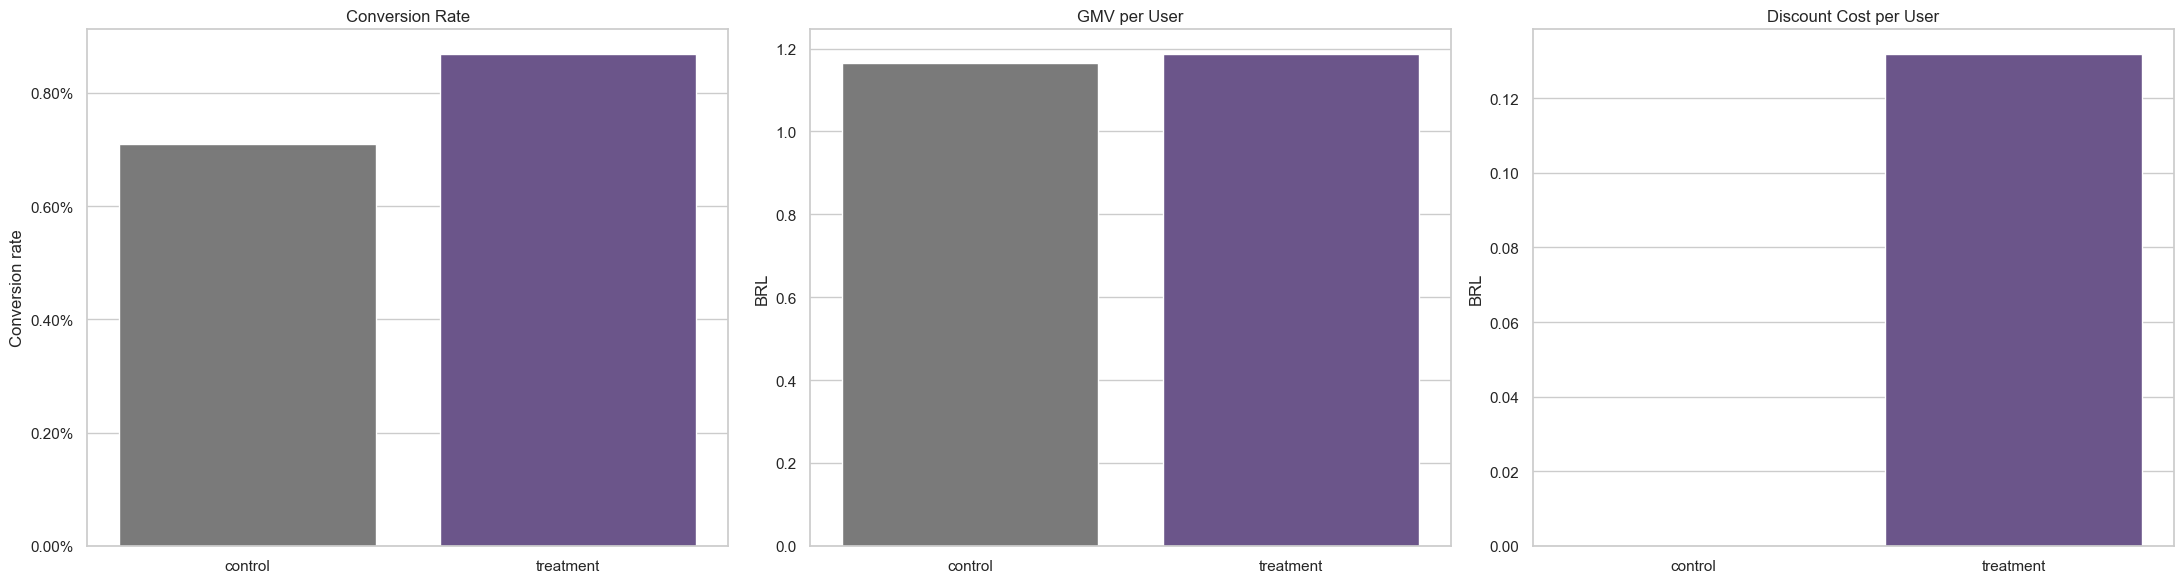

Conversion uplift: 0.16 percentage points
GMV per user uplift: BRL 0.02


In [95]:
from matplotlib.ticker import PercentFormatter

variant_palette = {
    "control": PALETTE["neutral"],
    "treatment": PALETTE["retention"],
}

fig, axes = plt.subplots(
    1,
    3,
    figsize=(22, 6),
)

sns.barplot(
    data=ab_summary,
    x="variant",
    y="conversion_rate",
    palette=variant_palette,
    ax=axes[0],
)

axes[0].set_title("Conversion Rate")
axes[0].set_xlabel("")
axes[0].set_ylabel("Conversion rate")
axes[0].yaxis.set_major_formatter(
    PercentFormatter(1)
)

sns.barplot(
    data=ab_summary,
    x="variant",
    y="gmv_per_user",
    palette=variant_palette,
    ax=axes[1],
)

axes[1].set_title("GMV per User")
axes[1].set_xlabel("")
axes[1].set_ylabel("BRL")

sns.barplot(
    data=ab_summary,
    x="variant",
    y="discount_cost_per_user",
    palette=variant_palette,
    ax=axes[2],
)

axes[2].set_title("Discount Cost per User")
axes[2].set_xlabel("")
axes[2].set_ylabel("BRL")

plt.tight_layout()

plt.savefig(
    IMAGE_DIR / "ab_test_results.png",
    bbox_inches="tight",
    dpi=300,
)

plt.show()

conversion_uplift_pp = (
    treatment["conversion"].mean()
    - control["conversion"].mean()
) * 100

gmv_uplift = (
    treatment["net_gmv"].mean()
    - control["net_gmv"].mean()
)

print(
    f"Conversion uplift: {conversion_uplift_pp:.2f} percentage points"
)

print(
    f"GMV per user uplift: BRL {gmv_uplift:.2f}"
)

> Interpretation
> * The treatment group achieves a small conversion uplift of **0.16 percentage points** compared with the control group.
> * Despite the higher conversion rate, the GMV per user uplift is only **BRL 0.02**, showing limited short-term financial improvement.
> * The discount creates an additional cost per user, which reduces the economic impact of the campaign.
> * This simulated experiment highlights an important marketplace trade-off: promotional incentives may improve activation, but they do not necessarily generate meaningful value unless margins, repeat behavior, or downstream monetization also improve.

# 7. Product and Business Strategy

The previous sections analyzed marketplace growth, customer behavior, logistics performance, seller quality, customer value, retention, and simulated promotional impact.

This final section translates the analytical findings into business strategy. The goal is to identify where the marketplace should prioritize investment, operational improvement, retention efforts, and quality control.

Rather than treating all customers, sellers, categories, and regions equally, the strategy focuses on the areas where value is most concentrated and where operational improvements could have the greatest long-term impact.

## 7.1 Marketplace Value Concentration

Before defining strategic recommendations, it is important to understand where marketplace value is concentrated.

This analysis compares how GMV accumulates across customers, sellers, and product categories. The goal is to identify where focused retention, seller management, and assortment decisions can create the highest business impact.

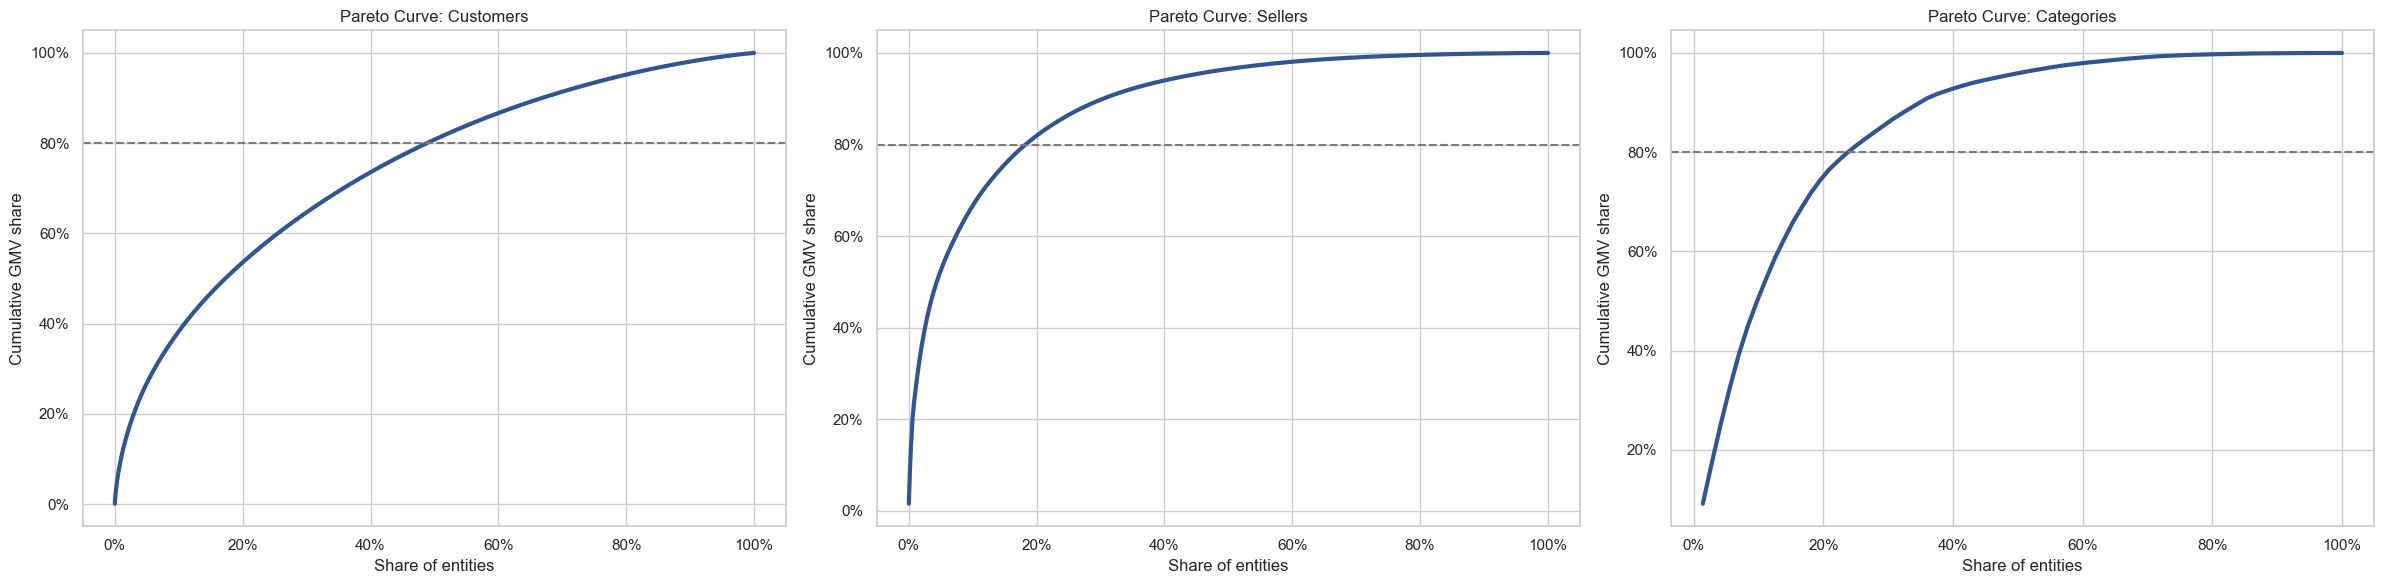

In [96]:
from matplotlib.ticker import PercentFormatter

def pareto_threshold_share(values, target_share=0.80):
    ordered = (
        pd.Series(values)
        .dropna()
        .sort_values(ascending=False)
        .reset_index(drop=True)
    )

    cumulative = ordered.cumsum() / ordered.sum()

    return (
        (cumulative <= target_share).sum() + 1
    ) / len(ordered)


customer_80_share = pareto_threshold_share(
    customer_level["realized_ltv"]
)

seller_80_share = pareto_threshold_share(
    seller_summary["gmv"]
)

category_80_share = pareto_threshold_share(
    category_summary["gmv"]
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(24, 6),
)

for ax, series, title in [
    (
        axes[0],
        customer_level["realized_ltv"],
        "Customers",
    ),
    (
        axes[1],
        seller_summary["gmv"],
        "Sellers",
    ),
    (
        axes[2],
        category_summary["gmv"],
        "Categories",
    ),
]:
    ordered = (
        pd.Series(series)
        .dropna()
        .sort_values(ascending=False)
        .reset_index(drop=True)
    )

    cumulative = ordered.cumsum() / ordered.sum()

    x = (
        ordered.index + 1
    ) / len(ordered)

    ax.plot(
        x,
        cumulative,
        linewidth=3,
        color=PALETTE["gmv"],
    )

    ax.axhline(
        0.8,
        linestyle="--",
        color=PALETTE["neutral"],
    )

    ax.set_title(f"Pareto Curve: {title}")
    ax.set_xlabel("Share of entities")
    ax.set_ylabel("Cumulative GMV share")

    ax.xaxis.set_major_formatter(
        PercentFormatter(1)
    )

    ax.yaxis.set_major_formatter(
        PercentFormatter(1)
    )

plt.tight_layout()

plt.savefig(
    IMAGE_DIR / "marketplace_value_concentration.png",
    bbox_inches="tight",
    dpi=300,
)

plt.show()

> Interpretation
> * About **48.8%** of customers generate 80% of marketplace GMV, confirming that customer value is meaningfully concentrated.
> * Roughly **18.3%** of sellers account for 80% of GMV, suggesting that seller enablement and quality management can focus on a smaller strategic group.
> * Approximately **25.0%** of categories generate 80% of marketplace GMV, indicating that assortment decisions should prioritize high-impact product verticals.
> * Overall, the marketplace should not treat customers, sellers, and categories equally: the highest business impact is likely concentrated in a smaller set of strategic segments.

## 7.2 Category Strategy by Customer Value Segment

After identifying where marketplace value is concentrated, the next step is to understand which categories matter most for different customer value segments.

This analysis compares the category mix of high-value and low-value customers, then classifies categories into strategic action groups: **Invest**, **Fix**, or **Rationalize / Monitor**.

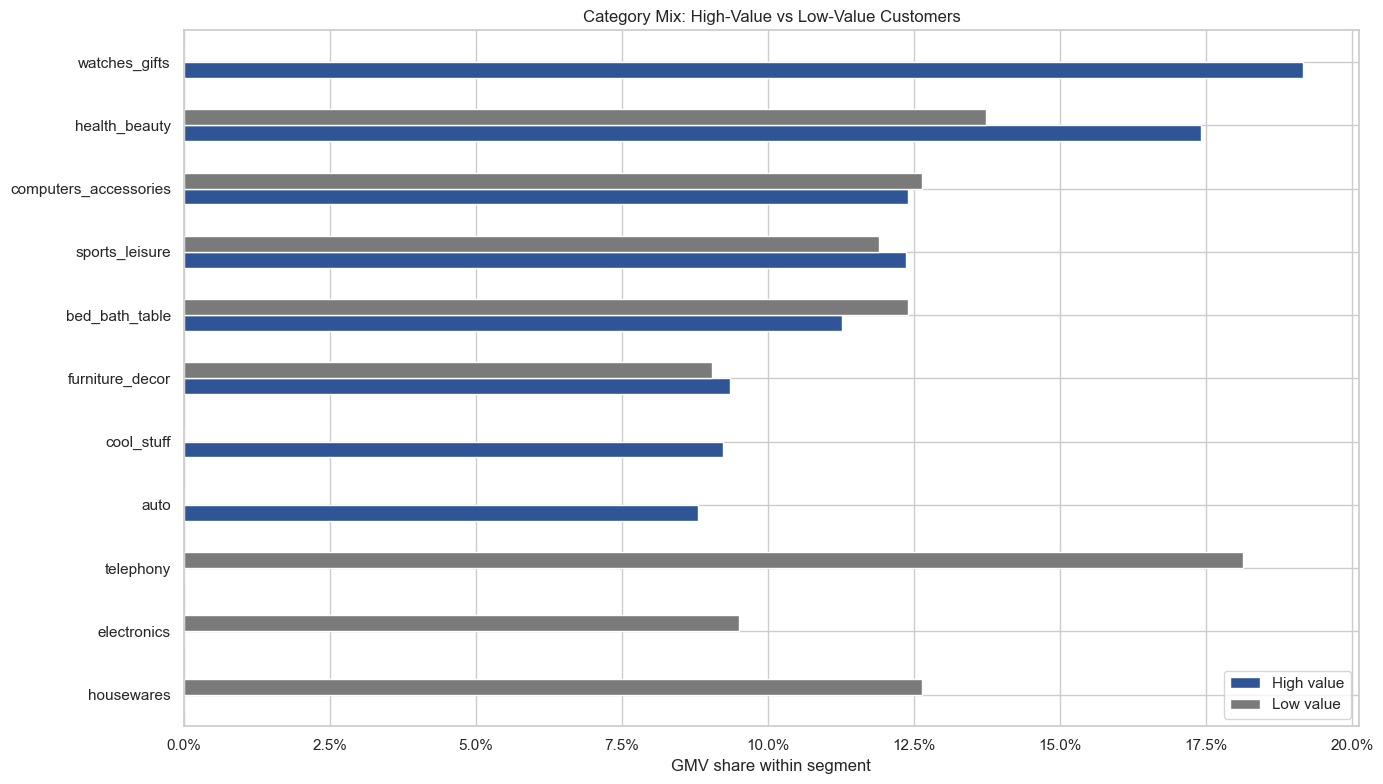

,strategic_action,product_category_name_english,gmv,avg_review,avg_freight_share
0,Fix,watches_gifts,"1,298,292.47",4.03,0.08
1,Fix,bed_bath_table,"1,240,386.13",3.90,0.16
2,Fix,computers_accessories,"1,050,941.58",3.95,0.14
3,Fix,furniture_decor,"899,626.04",3.92,0.19
4,Fix,housewares,"772,035.14",4.07,0.19
5,Invest,health_beauty,"1,437,665.78",4.15,0.13
6,Invest,sports_leisure,"1,147,244.63",4.12,0.15
7,Invest,cool_stuff,"704,086.24",4.16,0.12
8,Invest,auto,"678,606.64",4.08,0.14
9,Invest,toys,"556,783.29",4.18,0.14


In [97]:
from matplotlib.ticker import PercentFormatter

completed_items_query = """
SELECT
    order_id,
    customer_unique_id,
    product_category_name_english,
    item_gmv
FROM vw_completed_items
WHERE
    customer_unique_id IS NOT NULL
    AND product_category_name_english IS NOT NULL
    AND item_gmv IS NOT NULL;
"""

with engine.connect() as conn:
    completed_items = pd.read_sql(
        text(completed_items_query),
        conn,
    )

high_value_customers = set(
    customer_level.loc[
        customer_level["value_segment"] == "High",
        "customer_unique_id",
    ]
)

low_value_customers = set(
    customer_level.loc[
        customer_level["value_segment"] == "Low",
        "customer_unique_id",
    ]
)

high_mix = (
    completed_items[
        completed_items["customer_unique_id"]
        .isin(high_value_customers)
    ]
    .groupby("product_category_name_english")["item_gmv"]
    .sum()
    .sort_values(ascending=False)
    .head(8)
)

high_mix = (
    high_mix / high_mix.sum()
).rename("High value")

low_mix = (
    completed_items[
        completed_items["customer_unique_id"]
        .isin(low_value_customers)
    ]
    .groupby("product_category_name_english")["item_gmv"]
    .sum()
    .sort_values(ascending=False)
    .head(8)
)

low_mix = (
    low_mix / low_mix.sum()
).rename("Low value")

mix_compare = (
    pd.concat(
        [
            high_mix,
            low_mix,
        ],
        axis=1,
    )
    .fillna(0)
    .sort_values("High value", ascending=True)
)

gmv_high_cutoff = category_summary["gmv"].quantile(0.75)
gmv_low_cutoff = category_summary["gmv"].quantile(0.25)
review_cutoff = category_summary["avg_review"].median()

category_strategy = category_summary[
    [
        "product_category_name_english",
        "gmv",
        "avg_review",
        "avg_freight_share",
    ]
].copy()

category_strategy["strategic_action"] = np.select(
    [
        (
            (category_strategy["gmv"] >= gmv_high_cutoff)
            & (category_strategy["avg_review"] >= review_cutoff)
        ),
        (
            (category_strategy["gmv"] >= gmv_high_cutoff)
            & (category_strategy["avg_review"] < review_cutoff)
        ),
        (
            (category_strategy["gmv"] <= gmv_low_cutoff)
            & (category_strategy["avg_review"] < review_cutoff)
        ),
    ],
    [
        "Invest",
        "Fix",
        "Rationalize / Monitor",
    ],
    default="Maintain",
)

strategy_display = (
    category_strategy[
        category_strategy["strategic_action"] != "Maintain"
    ]
    .sort_values(
        [
            "strategic_action",
            "gmv",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .groupby(
        "strategic_action",
        group_keys=False,
    )
    .head(5)
    .reset_index(drop=True)
)

segment_palette = {
    "High value": PALETTE["gmv"],
    "Low value": PALETTE["neutral"],
}

fig, ax = plt.subplots(
    figsize=(14, 8),
)

mix_compare.plot(
    kind="barh",
    ax=ax,
    color=[
        segment_palette["High value"],
        segment_palette["Low value"],
    ],
)

ax.set_title(
    "Category Mix: High-Value vs Low-Value Customers"
)

ax.set_xlabel(
    "GMV share within segment"
)

ax.xaxis.set_major_formatter(
    PercentFormatter(1)
)

ax.set_ylabel("")

plt.tight_layout()

plt.savefig(
    IMAGE_DIR / "category_strategy_by_value_segment.png",
    bbox_inches="tight",
    dpi=300,
)

plt.show()

display(
    strategy_display[
        [
            "strategic_action",
            "product_category_name_english",
            "gmv",
            "avg_review",
            "avg_freight_share",
        ]
    ]
    .round(2)
)

> Interpretation
> * High-value customers are more concentrated in categories such as **watches_gifts**, **health_beauty**, **sports_leisure**, and **computers_accessories**, suggesting strong potential for targeted retention and personalization.
> * Categories classified as **Invest** combine meaningful GMV with stronger review performance, making them good candidates for merchandising, retention, and targeted growth efforts.
> * Categories classified as **Fix** generate strong GMV but show weaker customer experience indicators, suggesting that operational improvements should come before aggressive growth investment.
> * Categories classified as **Rationalize / Monitor** have lower GMV and weaker satisfaction signals, making them candidates for seller remediation, assortment review, or reduced promotional support.

# 8. Predictive Modeling: GMV Prediction

This section adds a lightweight predictive modeling layer to the marketplace analysis.

The goal is to predict order-level GMV using features related to basket structure, product mix, seller geography, logistics, and payment behavior. Because marketplace GMV is highly right-skewed, the target is log-transformed during training to reduce the influence of extreme orders and improve model stability.

This model should not be interpreted as a pricing model. It is better understood as a practical forecasting aid for GMV banding, merchandising analysis, and logistics planning.

## 8.1 Model Dataset Preparation

The predictive model starts by building an order-level modeling dataset from completed marketplace item transactions.

To keep the feature space manageable, less frequent product categories and customer/seller states are grouped as **other**. The target variable is order-level GMV, transformed with **log1p** to reduce the influence of extreme order values and improve model stability.

In [98]:
model_items_query = """
SELECT
    order_id,
    order_item_id,
    customer_state,
    seller_state,
    product_category_name_english,
    item_gmv,
    product_weight_g,
    volume_cm3,
    seller_id,
    same_state_route,
    payment_installments,
    payment_type
FROM vw_completed_items
WHERE
    order_id IS NOT NULL
    AND item_gmv IS NOT NULL
    AND item_gmv > 0;
"""

with engine.connect() as conn:
    model_items = pd.read_sql(
        text(model_items_query),
        conn,
    )

top_categories_model = (
    model_items["product_category_name_english"]
    .value_counts()
    .head(20)
    .index
)

top_customer_states = (
    model_items["customer_state"]
    .value_counts()
    .head(10)
    .index
)

top_seller_states = (
    model_items["seller_state"]
    .value_counts()
    .head(10)
    .index
)

model_items["category_group"] = (
    model_items["product_category_name_english"]
    .where(
        model_items["product_category_name_english"]
        .isin(top_categories_model),
        "other",
    )
)

model_items["customer_state_group"] = (
    model_items["customer_state"]
    .where(
        model_items["customer_state"]
        .isin(top_customer_states),
        "other",
    )
)

model_items["seller_state_group"] = (
    model_items["seller_state"]
    .where(
        model_items["seller_state"]
        .isin(top_seller_states),
        "other",
    )
)

model_items["payment_type"] = (
    model_items["payment_type"]
    .replace(
        {
            "boleto": "bank_slip",
            "credit_card": "credit_card",
            "debit_card": "debit_card",
            "voucher": "voucher",
        }
    )
)

model_orders = (
    model_items
    .groupby(
        "order_id",
        as_index=False,
    )
    .agg(
        gmv=("item_gmv", "sum"),
        item_count=("order_item_id", "count"),
        category_count=("category_group", "nunique"),
        main_category=("category_group", mode_or_first),
        avg_weight_g=("product_weight_g", "mean"),
        avg_volume_cm3=("volume_cm3", "mean"),
        seller_count=("seller_id", "nunique"),
        main_seller_state=("seller_state_group", mode_or_first),
        customer_state=("customer_state_group", mode_or_first),
        same_state_share=("same_state_route", "mean"),
        payment_installments=("payment_installments", "max"),
        payment_type=("payment_type", mode_or_first),
    )
)

sample_size = min(
    40000,
    len(model_orders),
)

model_orders = (
    model_orders
    .sample(
        n=sample_size,
        random_state=42,
    )
)

feature_cols = [
    "item_count",
    "category_count",
    "main_category",
    "avg_weight_g",
    "avg_volume_cm3",
    "seller_count",
    "main_seller_state",
    "customer_state",
    "same_state_share",
    "payment_installments",
    "payment_type",
]

numeric_features = [
    "item_count",
    "category_count",
    "avg_weight_g",
    "avg_volume_cm3",
    "seller_count",
    "same_state_share",
    "payment_installments",
]

categorical_features = [
    "main_category",
    "main_seller_state",
    "customer_state",
    "payment_type",
]

X = model_orders[feature_cols]
y = np.log1p(
    model_orders["gmv"]
)

display(
    model_orders[
        feature_cols + ["gmv"]
    ]
    .head()
    .round(2)
)

,item_count,category_count,main_category,avg_weight_g,avg_volume_cm3,seller_count,main_seller_state,customer_state,same_state_share,payment_installments,payment_type,gmv
5718,1,1,computers_accessories,175.00,"8,000.00",1,SP,RS,0.00,2.00,credit_card,196.01
85240,1,1,pet_shop,"1,400.00","24,000.00",1,MG,SP,0.00,1.00,credit_card,96.81
71670,1,1,sports_leisure,"17,650.00","105,840.00",1,SP,SP,1.00,10.00,credit_card,699.94
2544,1,1,other,"2,750.00","9,375.00",1,SP,SP,1.00,1.00,bank_slip,105.37
11006,4,2,baby,"2,675.00","32,560.00",1,SP,RS,0.00,4.00,credit_card,293.64


> Interpretation
> * The modeling dataset combines basket structure, product attributes, seller geography, customer geography, route structure, and payment behavior into one row per order.
> * Less frequent categories and states are grouped as **other** to reduce sparsity and keep the model practical.
> * The target variable is order-level GMV, not platform revenue, which keeps the modeling objective aligned with the dataset limitations.
> * GMV is log-transformed for training because marketplace order values are highly right-skewed.
> * Payment types are standardized for readability, with **boleto** represented as **bank_slip**.

## 8.2 Model Training and Evaluation

The modeling pipeline combines preprocessing and prediction into a single workflow.

Numeric variables are imputed with median values, while categorical variables are encoded with one-hot encoding. A Random Forest regressor is then trained to predict log-transformed order-level GMV.

The evaluation focuses on practical forecasting usefulness rather than perfect order-level precision.

In [99]:
(
    X_train,
    X_test,
    y_train,
    y_test,
    gmv_train,
    gmv_test,
) = train_test_split(
    X,
    y,
    model_orders["gmv"],
    test_size=0.25,
    random_state=42,
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                [
                    (
                        "imputer",
                        SimpleImputer(strategy="median"),
                    )
                ]
            ),
            numeric_features,
        ),
        (
            "cat",
            Pipeline(
                [
                    (
                        "imputer",
                        SimpleImputer(
                            strategy="most_frequent"
                        ),
                    ),
                    (
                        "onehot",
                        OneHotEncoder(
                            handle_unknown="ignore"
                        ),
                    ),
                ]
            ),
            categorical_features,
        ),
    ]
)

gmv_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor,
        ),
        (
            "model",
            RandomForestRegressor(
                n_estimators=80,
                min_samples_leaf=5,
                max_depth=14,
                random_state=42,
                n_jobs=1,
            ),
        ),
    ]
)

gmv_model.fit(X_train, y_train)

gmv_pred = np.expm1(
    gmv_model.predict(X_test)
)

mae = mean_absolute_error(
    gmv_test,
    gmv_pred,
)

r2 = r2_score(
    gmv_test,
    gmv_pred,
)

median_abs_error = np.median(
    np.abs(gmv_test - gmv_pred)
)

model_metrics = pd.DataFrame(
    {
        "metric": [
            "MAE",
            "Median absolute error",
            "R-squared",
            "Sampled orders",
        ],
        "value": [
            mae,
            median_abs_error,
            r2,
            sample_size,
        ],
    }
)

display(model_metrics.round(2))

,metric,value
0,MAE,63.72
1,Median absolute error,25.85
2,R-squared,0.37
3,Sampled orders,"40,000.00"


> Interpretation
> * The model achieves an MAE of approximately **BRL 64** and a median absolute error near **BRL 26**, suggesting that predictions are useful for directional GMV banding, although individual order-level forecasts remain noisy.
> * The gap between MAE and median absolute error indicates that some large prediction errors remain, which is expected in a highly skewed marketplace GMV distribution.
> * An R-squared of approximately **0.37** shows that the model captures part of the commercial signal, but a large share of order-level variability remains unexplained.
> * The model should be interpreted as a lightweight operational forecasting tool, not as a precise pricing, revenue, or demand prediction system.

## 8.3 Model Interpretation and Feature Importance

After training the model, the next step is to understand how it behaves and which feature groups contribute most to GMV prediction.

The scatterplot compares predicted and actual order GMV, while the feature importance chart shows which business dimensions the model relies on most when estimating order value.

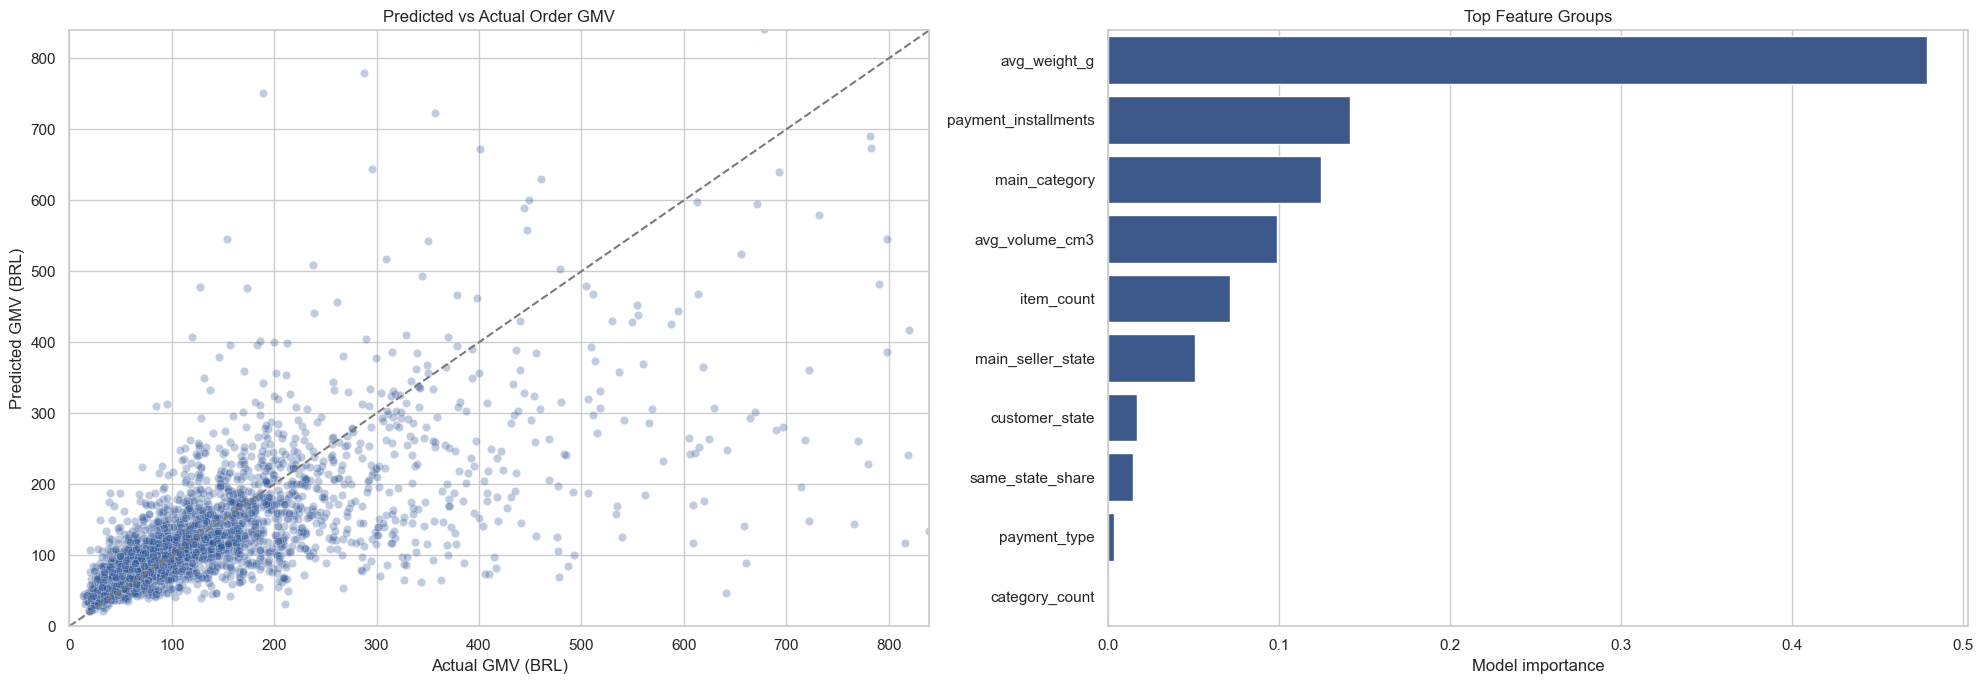

In [100]:
feature_names = (
    gmv_model.named_steps["preprocessor"]
    .get_feature_names_out()
)

importances = pd.DataFrame(
    {
        "feature": feature_names,
        "importance": (
            gmv_model.named_steps["model"]
            .feature_importances_
        ),
    }
)

def collapse_feature(name):
    cleaned = (
        name.replace("num__", "")
        .replace("cat__", "")
    )

    for original in sorted(
        feature_cols,
        key=len,
        reverse=True,
    ):
        if (
            cleaned == original
            or cleaned.startswith(original + "_")
        ):
            return original

    return cleaned


grouped_importance = (
    importances.assign(
        feature_group=importances["feature"].map(
            collapse_feature
        )
    )
    .groupby(
        "feature_group",
        as_index=False,
    )
    .agg(
        importance=("importance", "sum")
    )
    .sort_values(
        "importance",
        ascending=False,
    )
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(20, 7),
)

plot_sample = (
    pd.DataFrame(
        {
            "actual": gmv_test.reset_index(drop=True),
            "predicted": pd.Series(gmv_pred),
        }
    )
    .sample(
        n=min(3000, len(gmv_test)),
        random_state=42,
    )
)

sns.scatterplot(
    data=plot_sample,
    x="actual",
    y="predicted",
    color=PALETTE["gmv"],
    alpha=0.30,
    ax=axes[0],
)

max_axis = np.percentile(
    np.concatenate(
        [
            plot_sample["actual"],
            plot_sample["predicted"],
        ]
    ),
    99,
)

axes[0].plot(
    [0, max_axis],
    [0, max_axis],
    linestyle="--",
    color=PALETTE["neutral"],
)

axes[0].set_xlim(0, max_axis)
axes[0].set_ylim(0, max_axis)

axes[0].set_title(
    "Predicted vs Actual Order GMV"
)

axes[0].set_xlabel("Actual GMV (BRL)")
axes[0].set_ylabel("Predicted GMV (BRL)")

sns.barplot(
    data=grouped_importance.head(10),
    y="feature_group",
    x="importance",
    color=PALETTE["gmv"],
    ax=axes[1],
)

axes[1].set_title("Top Feature Groups")
axes[1].set_xlabel("Model importance")
axes[1].set_ylabel("")

plt.tight_layout()

plt.savefig(
    IMAGE_DIR / "predictive_modeling.png",
    bbox_inches="tight",
    dpi=300,
)

plt.tight_layout()
plt.show()

> Interpretation
> * The predicted vs actual plot shows that the model captures the general GMV pattern reasonably well for lower and mid-range orders, but becomes less precise as order value increases.
> * The most influential feature groups are **avg_weight_g**, **payment_installments**, **main_category**, **avg_volume_cm3**, and **item_count**.
> * This suggests that GMV prediction depends much more on basket composition and product characteristics than on geographic variables alone.
> * Features such as **customer_state**, **same_state_share**, **payment_type**, and **category_count** add comparatively little predictive signal in this setup.
> * Overall, the model is more useful for GMV banding and operational prioritization than for precise order-level forecasting.
> * As with any tree-based importance measure, these values reflect predictive usefulness rather than causal business impact.

# 9. Strategic Recommendations and Business Implications

In this final section, I translate the main findings from the notebook into practical business recommendations focused on marketplace growth, retention, logistics performance, and customer experience.

### Key Findings

- Marketplace GMV is diversified enough to avoid dependence on a single category, although a relatively small set of categories and sellers still explains most platform activity.
- **health_beauty** is the largest category by GMV, while **SP** remains the primary demand state of the marketplace.
- Retention is the main structural weakness of the marketplace: only **3.0%** of customers place more than one order, and average month-1 cohort retention is approximately **0.44%** among cohorts with at least 100 customers.
- Customer value is highly concentrated, with the highest-value segment contributing roughly **59%** of total GMV.
- Logistics quality is strongly associated with customer experience, since late deliveries and longer shipping routes consistently show weaker review scores.
- Product characteristics and basket composition contribute more to GMV prediction than geography alone, reinforcing the importance of assortment quality and merchandising strategy.

### Strategic Recommendations

- Increase investment in high-scale and high-satisfaction categories such as **health_beauty**, **sports_leisure**, and **cool_stuff** through stronger merchandising, loyalty initiatives, and cross-sell strategies.
- Prioritize operational improvements in large but weaker-experience categories such as **watches_gifts**, **bed_bath_table**, and **computers_accessories** before pushing aggressive growth in those verticals.
- Focus on second-purchase activation programs, since the largest customer value opportunity comes from improving purchase frequency rather than only increasing first-order basket size.
- Implement seller quality scorecards combining GMV, review score, late-delivery rate, and delivery reliability to reduce concentration risk and protect customer trust.
- Explore regional seller density and better inventory positioning to reduce cross-state logistics friction and freight pressure.

### Trade-Offs and Limitations

- The A/B test is simulated, so statistical significance reflects explicit modeling assumptions rather than causal evidence from a live randomized experiment.
- The predictive model is intentionally lightweight and designed for operational planning support rather than automated pricing or precise financial forecasting.
- The dataset is historical and does not include contribution margin, advertising spend, commissions, inventory costs, or operational costs, so profitability conclusions should be interpreted as directional rather than definitive.

### Next Steps

1. Run a real retention experiment targeting customers with high first-order satisfaction but low natural repeat probability.
2. Build seller and category monitoring dashboards combining GMV, late-delivery rate, freight intensity, and customer review metrics.
3. Add contribution margin data to evolve LTV and assortment decisions from GMV-based optimization toward profit-based optimization.